In [71]:
import numpy as np 
import matplotlib.pyplot as plt
import ipywidgets as ipw
import torch
import time
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

import programs.NN as NN
import programs.misc as misc
import programs.objects as obj 

from programs.main_dless import *
from programs.misc import *
from programs.visualize import *
from programs.RK import RK_solver

plt.rcParams['font.family'] = 'XCharter'
# plt.rcParams['font.family'] = 'Times New Roman'

In [72]:
torch.manual_seed(1234)
np.random.seed(1234)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device='cpu'
if device != 'cpu':
    torch.cuda.set_device(device)
print(device)

cuda:0


In [73]:
path = 'data/neural/beta0.0 chi0.5 cin0.25 t1 (1)'
# path = 'data/neural/beta2.5 chi0.5 cin0.25 L1 t2.0'
# path = 'data/neural/beta2.5 chi0.5 cin0.25,0.15 L2 t4'
net = Poisson_Convection.load(path, device=device, loadloss=False)
print (net,'\n', net.model)
# if device!='cpu':
    # for _ in tqdm(range(100)): net.make_distributed_points()

+-------------+----------------------------------------+--------+--------------+
| Adam_epochs | 3000                                   | lr     | 1e-05        |
+-------------+----------------------------------------+--------+--------------+
| epoch       | 54937                                  | c_cond | [0.385, 0.0] |
+-------------+----------------------------------------+--------+--------------+
| path        | data/May/5                             | times  | [0.5]        |
+-------------+----------------------------------------+--------+--------------+
| weights     | [5.0, 5.0, 2.0, 3.0, 1.0, 1.0, 0.0,    | w_name | const        |
|             | 0.0]                                   |        |              |
+-------------+----------------------------------------+--------+--------------+
| alpha       | 1.000                                  | N_IC   | 64           |
+-------------+----------------------------------------+--------+--------------+
| zeta        | 0.500       

In [74]:
w0 = 1
mu0 = 0.01
cmax = 0.65

chi = 0.5
H = 1
L = net.alpha * H
u_in = net.kappa * L
T = net.t_max*net.kappa
# T = 1

pc = 12 * mu0 * u_in * L / w0**2 

Nx = 501
Ny = 501
Nt = 151

x_Tensor = torch.linspace(0, 1, Nx)
y_Tensor = torch.linspace(0, 1, Ny)
t_Tensor = torch.linspace(0, T, Nt)

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)
t = np.linspace(0, T, Nt)

dx = L / (Nx - 1)
dy = H / (Ny - 1)

mesh_xy, mesh_yx = np.meshgrid(x,y)
mesh_ty, mesh_yt = np.meshgrid(t,y)

mesh_XYT = torch.stack(torch.meshgrid(x_Tensor,y_Tensor,t_Tensor, indexing='ij')).reshape(3, -1).T
mesh_X = mesh_XYT[:,0]
mesh_Y = mesh_XYT[:,1]
mesh_T = mesh_XYT[:,2]

K = net.l(net.N_BC)**2
N = net.N_BC2
T

1.0

In [75]:
net.eval()

c, px, py, ux, uy, mu, conv, div, corr = [], [], [], [], [], [], [], [], []



for i in tqdm(t_Tensor):
    mesh_XYT = torch.stack(torch.meshgrid(x_Tensor,y_Tensor,i, indexing='ij')).reshape(3, -1).T
    X = torch.autograd.Variable(mesh_XYT[:,0], requires_grad=True)
    Y = torch.autograd.Variable(mesh_XYT[:,1], requires_grad=True)
    T = torch.autograd.Variable(mesh_XYT[:,2], requires_grad=True)
    BETA = torch.autograd.Variable(net.beta*torch.ones_like(X), requires_grad=True)

    c.append( net.get_c(X,Y,T,  BETA).reshape(Nx,  Ny).transpose(1,0))
    px.append(net.get_px(X,Y,T, BETA).reshape(Nx, Ny).transpose(1,0))
    py.append(net.get_py(X,Y,T, BETA).reshape(Nx, Ny).transpose(1,0))
    ux.append(net.get_ux(X,Y,T, BETA).reshape(Nx, Ny).transpose(1,0))
    uy.append(net.get_uy(X,Y,T, BETA).reshape(Nx, Ny).transpose(1,0))
    # conv.append(net.get_conv(X,Y,T).reshape(Nx, Ny).transpose(1,0) / (net.w_func(X,Y).max()**3).data.cpu().numpy())
    # div.append(net.get_div(X,Y,T).reshape(Nx, Ny).transpose(1,0) / (net.w_func(X,Y).max()**3).data.cpu().numpy())
    # corr.append(net.get_corr(X,Y,T).reshape(Nx, Ny).transpose(1,0))

# for i in tqdm(y_Tensor):
#     mesh_XYT = torch.stack(torch.meshgrid(x_Tensor,i,t_Tensor, indexing='ij')).reshape(3, -1).T
#     X = torch.autograd.Variable(mesh_XYT[:,0], requires_grad=True)
#     Y = torch.autograd.Variable(mesh_XYT[:,1], requires_grad=True)
#     T = torch.autograd.Variable(mesh_XYT[:,2], requires_grad=True)
#     BETA = torch.autograd.Variable(net.beta*torch.ones_like(X), requires_grad=True)

#     c.append(net.get_c(X,Y,T,BETA).reshape(Ny,Nt).transpose(1,0))

c = np.array(c) * cmax
px = np.array(px) * pc
py = np.array(py) * pc
ux = np.array(ux) * u_in
uy = np.array(uy) * u_in
conv = np.array(conv)
cx = np.array(conv)
div = np.array(div)
corr = np.array(corr)
total = net.weights[0]*np.abs(conv) + net.weights[1]*np.abs(div) + net.weights[2]*np.abs(corr)

100%|██████████| 151/151 [00:24<00:00,  6.16it/s]


In [30]:
# xxx = torch.autograd.Variable(torch.linspace(-0.5, 1.5, 500), requires_grad=True)
# plt.figure(figsize=(9,8), dpi=300)
# plt.plot(xxx.data.cpu(), net.soft_relu(xxx).data.cpu(), c='black')
# plt.plot(xxx.data.cpu(), misc.derivative(net.soft_relu(xxx), xxx).data.cpu(), c='red')
# plt.grid()
# plt.axis('square')
# plt.ylim(-0.25, 1.25)
# pass

In [8]:
M = 501
init_dict = {'chi':  chi,
             'mu0':  mu0,
             'cmax': cmax,
             'beta': -net.beta,
             'v':    u_in,
             'rho1': 1,
             'rho2': 1,
             'g' :   0,
             'w0':   w0,
             'c_in_arr':       [i*cmax for i in net.c_cond],
             'c_in_durations': [0.5],
             'Nt':  101,
             'Nx':  M,
             'Ny':  M,
             'L':   L,
             'H':   H,
             'dT':  0.01,
             'CFL': 0.5,
             # 1, 2, 3
             'rk_stages': 3,
             # True, False
             'use_WENO': False,
             # 'Z', 'M', smth else
             'WENO_type': 'Z',
             # 'minmod', 'van' 
             'lim_type': 'minmod',
             #'force', smth else
             'riemann' : '_',
             # True, False
             'prefer_sparse': True,
              }
solver = RK_solver(init_dict)
pass

In [9]:
solver.load('data/numerical/beta2.5 chi0.5 cin0.25 t2.0')

Recomputing velocities:   0%|          | 0/201 [00:00<?, ?it/s]

In [36]:
k = -1
print (solver.times[k])

try: all_c = list(c) + list((solver.Q[k]/solver.w).reshape(1,M,M)) #[-1].reshape(1,N,N)
except: all_c = list(c)
try: all_ux = list(ux) + list(solver.Vx[k].reshape(1,M,M+1))
except: all_ux = list(ux)
try: all_uy = list(uy) + list(solver.Vy[k].reshape(1,M+1,M))
except: all_uy = list(uy)

2.0


In [37]:
t

array([0.])

In [42]:
def plot_results(data,
                 N: int,
                 limits: list,
                 path: str = '',
                 cmaps: list = None,
                 title: list = None,
                 lims: list = None,
                 cbar_labels: list = None,
                 tick_step: float = 0.25
                 ):
    """
    Plots data from Neural Network

    Parameters:
    -----------
    data : list[np.ndarray]
        List of M arrays, each shaped (N, H, W)
    N : int
        Number of rows in the plot grid
    limits : list[float]
        Plotting area limits [x_min, x_max, y_min, y_max]
    path : str
        Path to save the figure
    cmaps : list[str]
        List of colormaps per column (length M)
    title : list[list[str]]
        Titles for each subplot, shape (M, N)
    lims : list[list[float]]
        List of [vmin, vmax] per column (length M)
    cbar_labels : list[str]
        Labels for colorbars (length M)
    tick_step : float
        Tick step on both axes
    """

    x_min, x_max, y_min, y_max = limits
    M = len(data)

    if cmaps is None:
        cmaps = ['turbo'] * M

    if cbar_labels is None:
        cbar_labels = [f'$f_{i}$' for i in range(1, M + 1)]

    if title is None:
        title = [[f'$f_{col}(x,y)$' for _ in range(N)] for col in range(M)]

    if lims is None:
        lims = [[np.min(data[col]), np.max(data[col])] for col in range(M)]

    height_ratios = []
    for i in range(2 * N - 1):
        if i % 2 == 0:
            height_ratios.append(1)
        elif i == 2 * N - 3:
            height_ratios.append(0.5 * N / (N + 1) + 0.5)
        else:
            height_ratios.append(0.5 * N / (N + 1))

    width_inches = M * 3
    height_inches = 2 * N + 0.5
    fig = plt.figure(figsize=(width_inches, height_inches), dpi=300)

    gs = gridspec.GridSpec(
        nrows=2 * N - 1,
        ncols=M,
        height_ratios=height_ratios,
        hspace=0.0,
        wspace=0.4
    )

    im_list = []
    axes = [[None] * M for _ in range(N)]

    for row in range(N):
        for col in range(M):
            ax = fig.add_subplot(gs[row * 2, col])
            im = ax.imshow(data[col][row], cmap=cmaps[col],
                           vmin=lims[col][0], vmax=lims[col][1],
                           extent=[x_min, x_max, y_max, y_min])
            ax.set_title(title[col][row], fontsize=9, pad=6)
            ax.invert_yaxis()
            ax.set_xlabel('x, м', fontsize=8)
            ax.set_ylabel('y, м', fontsize=8)
            ax.set_xticks(np.arange(x_min, x_max + tick_step, tick_step))
            ax.set_yticks(np.arange(y_min, y_max + tick_step, tick_step))
            ax.tick_params(axis='both', which='major', labelsize=5)
            ax.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
            axes[row][col] = ax
            im_list.append(im)

    for col in range(M):
        ax_last = axes[N - 1][col]
        ax_prev = axes[N - 2][col]

        pos_last = ax_last.get_position()
        pos_prev = ax_prev.get_position()

        center_y = (pos_last.y0 + pos_prev.y1) / 2
        height = 0.012

        cax = fig.add_axes([pos_last.x0, center_y - height / 2, pos_last.width, height])
        cbar = fig.colorbar(im_list[(N - 1) * M + col], cax=cax, orientation='horizontal')
        cax.set_xlabel(cbar_labels[col], fontsize=8, labelpad=2)
        cax.tick_params(labelsize=6)

    plt.show()

    if path:
        fig.savefig(path, bbox_inches='tight')


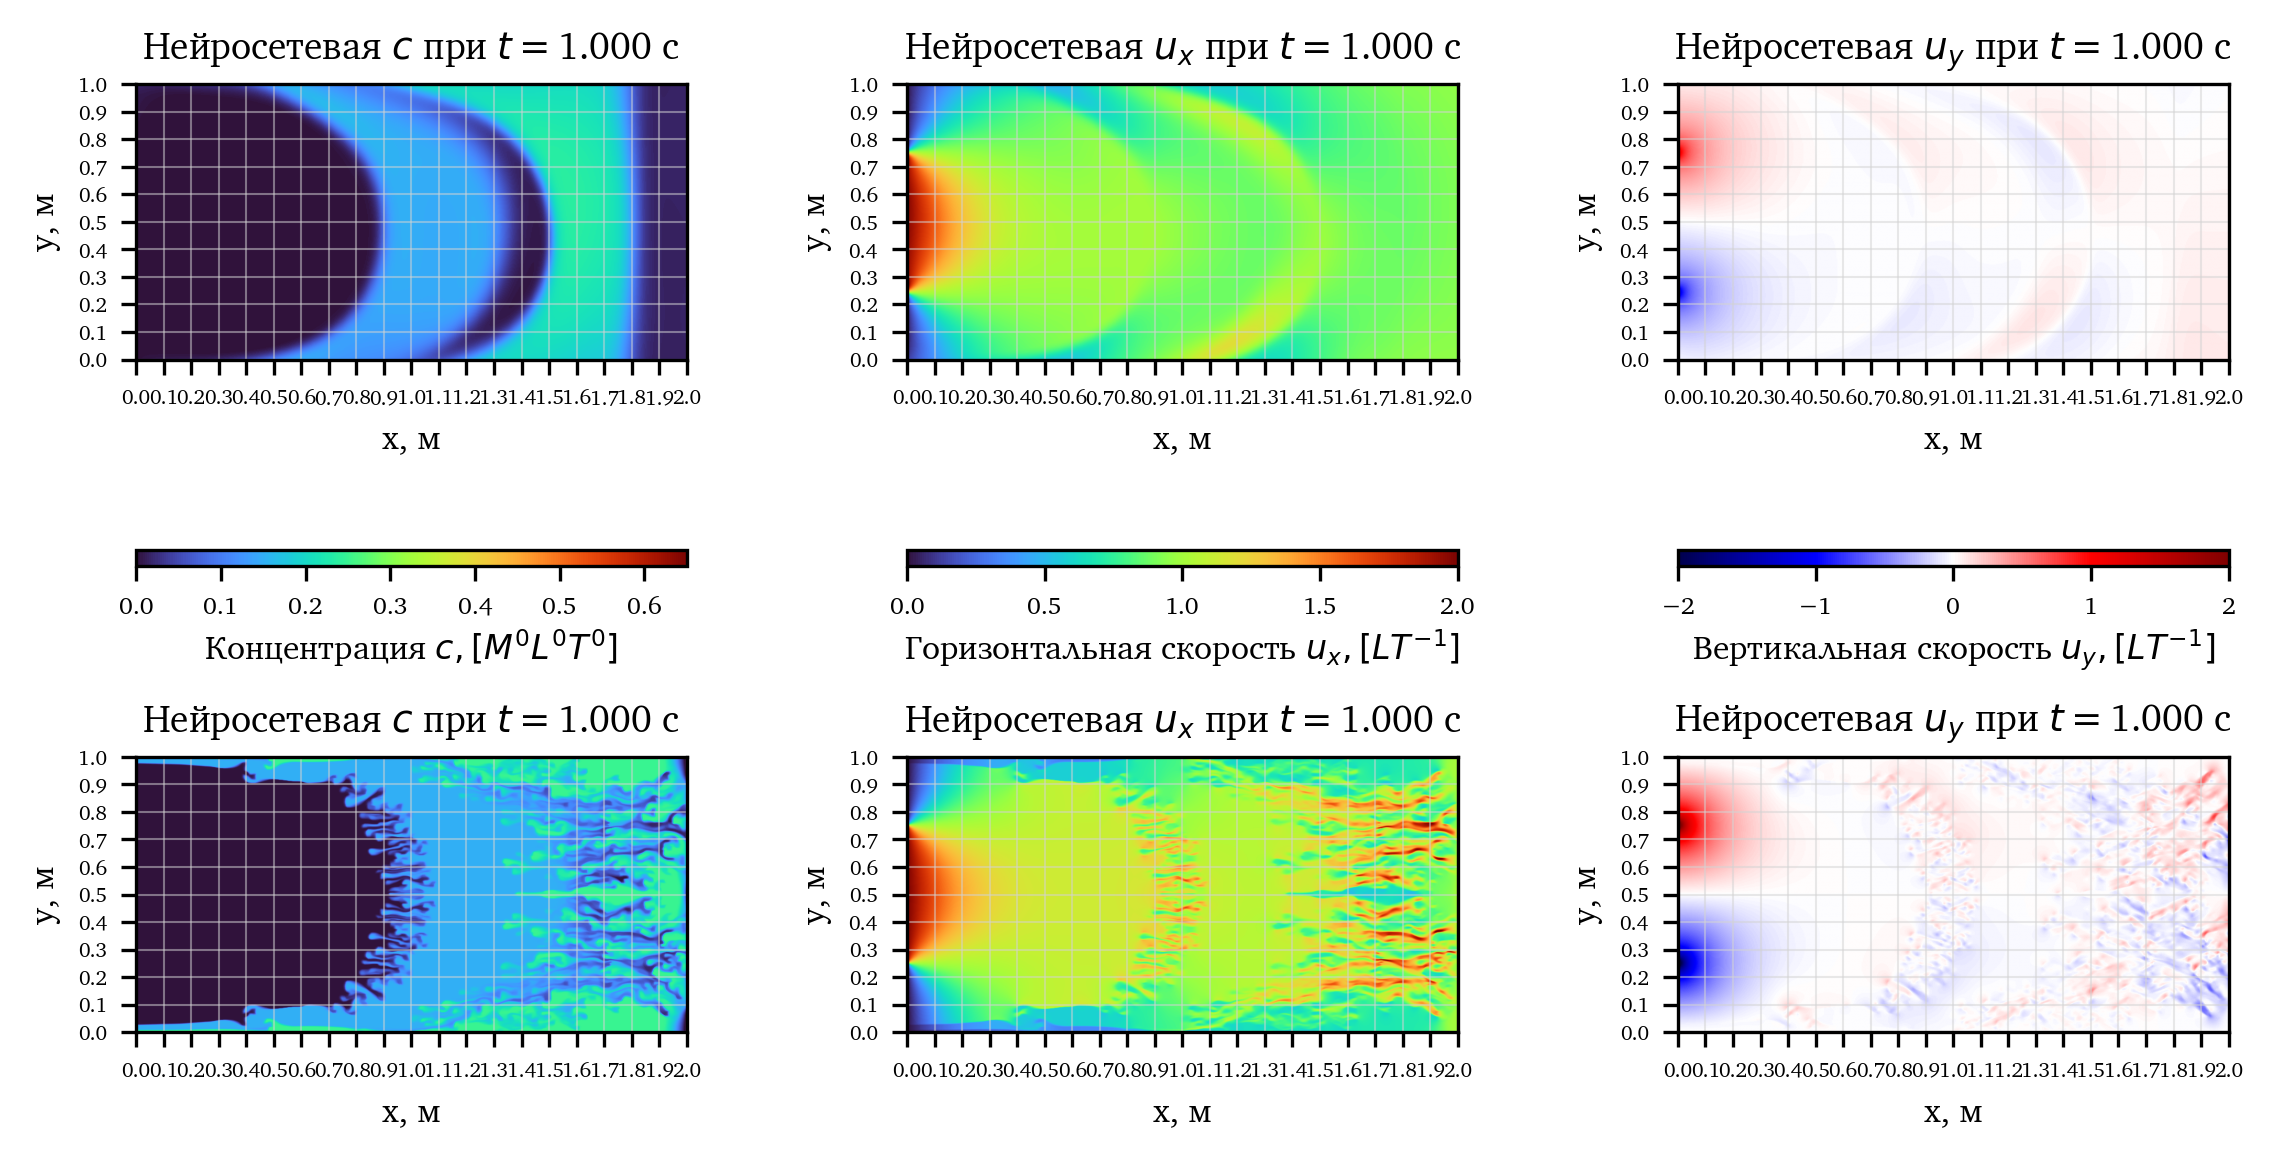

In [43]:
data = [all_c, all_ux, all_uy]
lims=[[0,cmax], [0,u_in], [-2,2]]
# labels = ['Concentration $c, [M^0L^0T^0]$', 'Horizontal velocity $u_x, [L T^{-1}]$', 'Vertical velocity $u_y, [L T^{-1}]$']
labels = ['Концентрация $c, [M^0L^0T^0]$', 'Горизонтальная скорость $u_x, [L T^{-1}]$', 'Вертикальная скорость $u_y, [L T^{-1}]$']
# data = [c, px, py]
# lims=[[0,cmax], [0,1], [-2,2]]
# data = [conv, div, corr]
# lims=[[0,cmax], [0,1], [-2,2]]
titles = [[f'Нейросетевая $c$ при $t=${1.:.3f} с' for i in t]   + [f'Численная $c$ при $t={t[-1]:.3f} с$'],
          [f'Нейросетевая $u_x$ при $t=${1.:.3f} с' for i in t] + [f'Численная $u_x$ при $t={t[-1]:.3f} с$'],
          [f'Нейросетевая $u_y$ при $t=${1.:.3f} с' for i in t] + [f'Численная $u_y$ при $t={t[-1]:.3f} с$']]
# titles = [[f'Neural $c$ at $t=${t[-1]}'] + [f'True $c$ at $t={t[-1]}$'], [f'Neural $u_x$ at $t=${t[-1]}'] + [f'True $u_x$ at $t={t[-1]}$'], [f'Neural $u_y$ at $t=${t[-1]}'] + [f'True $u_y$ at $t={t[-1]}$']]
plot_results(data=data, N=len(data[0]), limits=[0, L, 0, H], title=titles, cmaps=['turbo','turbo','seismic'], lims=lims, cbar_labels=labels, tick_step=0.1)
pass

In [18]:
c[-1].shape

(501, 501)

In [44]:
np.sum(np.abs(c[-1] - solver.Q[-1]/solver.w)) / len(c[-1].flatten())

np.float64(0.05095546207763144)

In [46]:
if k==-1:
    print (f'MAE:{np.sum(np.abs(c[-1] - solver.Q[-1]/solver.w))/len(c.flatten())}')
else:
    print (f'MAE:{np.sum(np.abs(c - solver.Q[:k+1]/solver.w))/len(c.flatten())}')

MAE:0.05095546207763144


(101,) (101,)
MAE: 0.010441239690869146


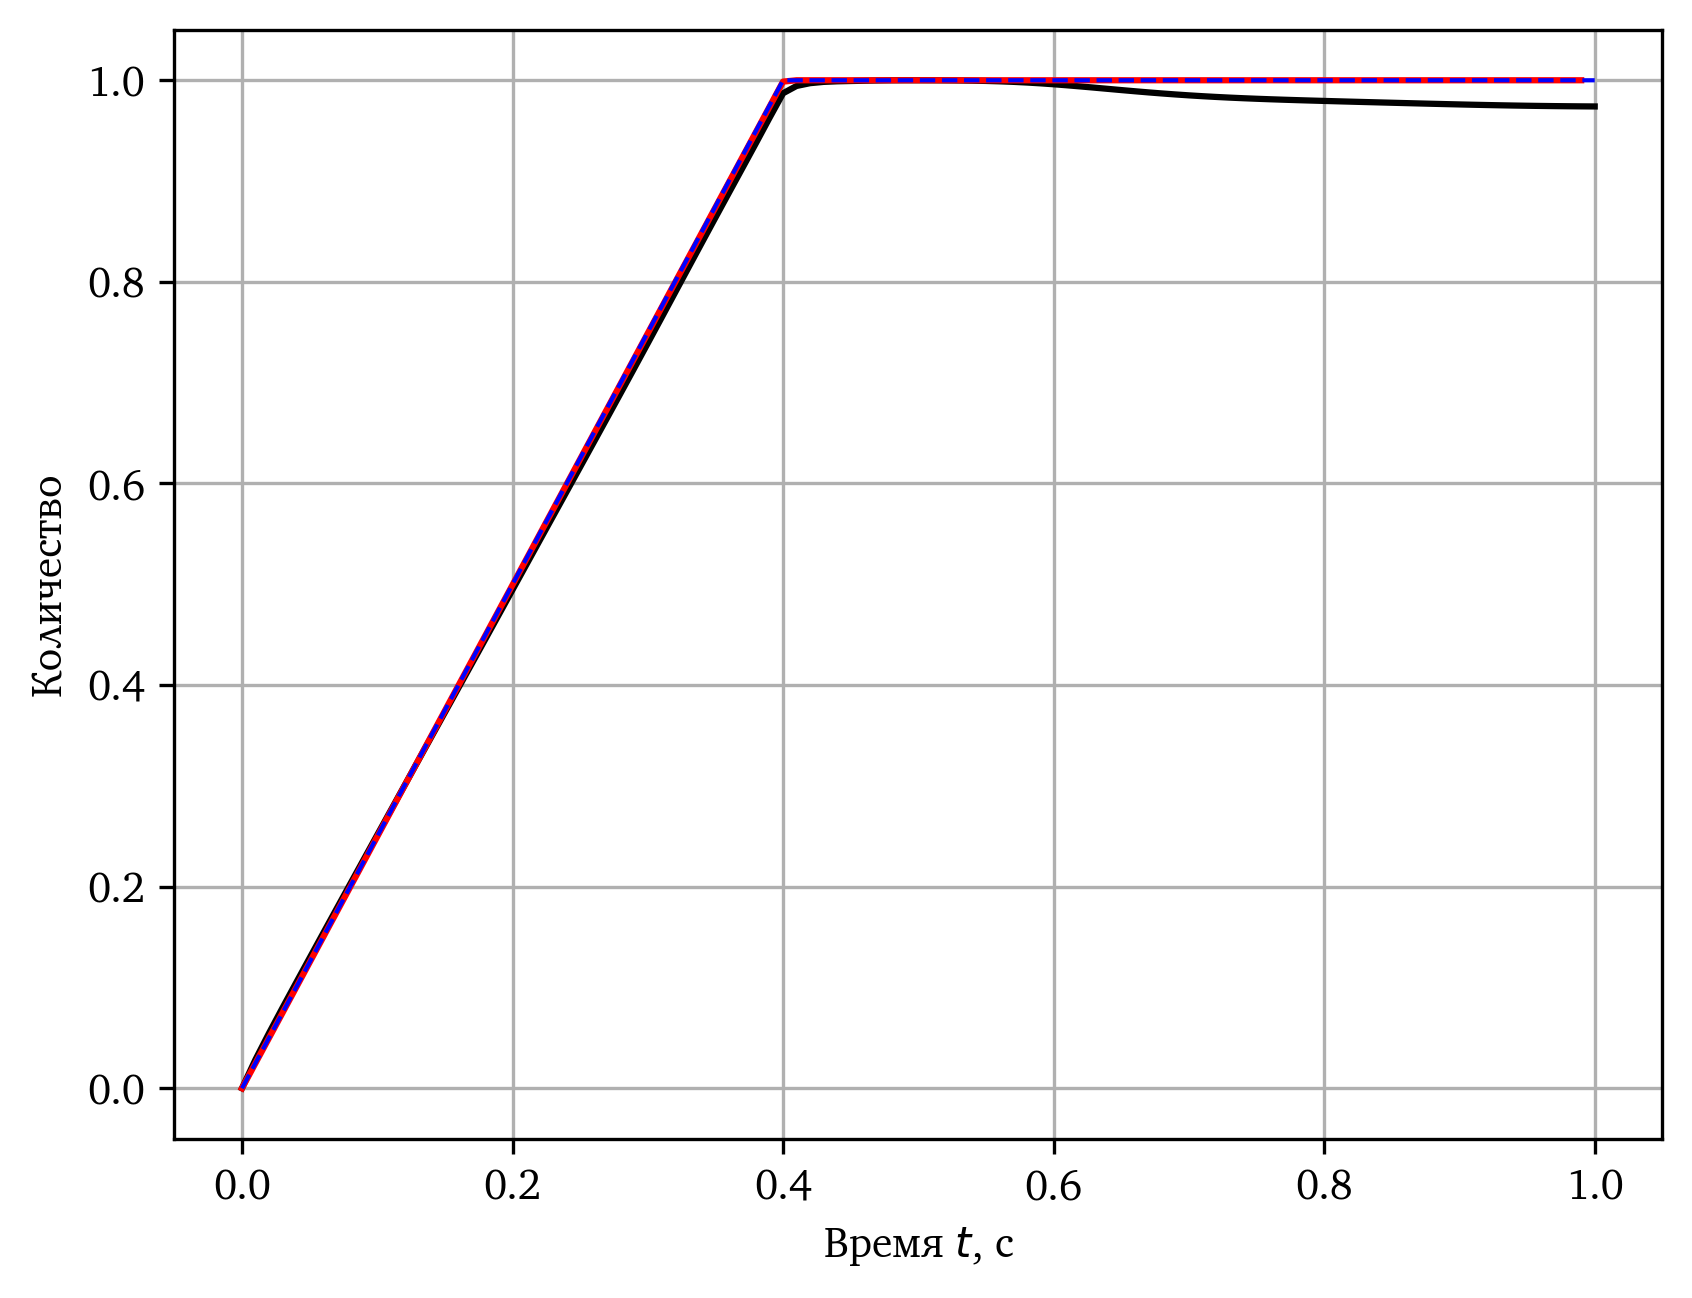

In [16]:
ttrue = np.zeros_like(t)
q_in_time = np.array([np.sum(Q) for Q in solver.Q])*solver.dx*solver.dy
times = [0] + net.times + [t[-1]]
a = []
for i in range(1, len(net.c_cond)+1):
    ttrue = np.where((t<=times[i]) & (t>times[i-1]), net.c_cond[i-1]*(t - times[i-1])*np.sum(u_in*np.ones_like(y))*dy+np.sum(a)*np.sum(u_in*np.ones_like(y))*(times[i] - times[i-1])*dy, ttrue)
    if net.c_cond[i-1]==0:
        a.append(net.c_cond[i-2])
        ttrue =  np.where((t<=times[i]) & (t>times[i-1]), np.sum(a)*np.sum(u_in*np.ones_like(y))*(times[i-1] - times[i-2])*dy, ttrue)
sums = []
for j in c:
    sums.append(np.sum(j))
plt.figure(dpi=300)
plt.grid()

sums = (sums - np.min(sums)) / (np.max(sums) - np.min(sums))
ttrue /= np.max(ttrue)

print (np.array(sums).shape, ttrue.shape)

colors = ['black', 'red', 'blue', 'green']
labels = ['Исходное решение', '1 эпоха', '2 эпоха', '3 эпоха']
plt.plot(t, sums, label='Нейросетевое', c=colors[0])
plt.plot(solver.times[:k], ((q_in_time - np.min(q_in_time)) / (np.max(q_in_time) - np.min(q_in_time)))[:k], label='Численное', c=colors[1])
plt.plot(t, ttrue, c='blue', linewidth=1, ls='--', label='Истина')
# plt.legend()
plt.xlabel('Время $t$, с')
plt.ylabel('Количество')

print (f'MAE: {np.sum(np.abs(ttrue - sums))/len(t)}')

In [77]:
# Рисунок 2: применимость метода адаптивных точек

nets = []
path = 'data/neural/beta0.0 chi0.5 cin0.25 t1 ('
for i in range(4):
    nets.append(Poisson_Convection.load(path+f'{i})', device=device, loadloss=False))

c_for4 = []
t_Tensor = torch.linspace(0, nets[0].t_max, 2)
t_for4 = np.linspace(0, nets[0].t_max, 2)

for net in ([nets[0]] + [nets[1]]):
    ci = []
    for i in tqdm(t_Tensor):
        mesh_XYT = torch.stack(torch.meshgrid(x_Tensor,y_Tensor,i, indexing='ij')).reshape(3, -1).T
        XX = torch.autograd.Variable(mesh_XYT[:,0], requires_grad=True)
        YY = torch.autograd.Variable(mesh_XYT[:,1], requires_grad=True)
        TT = torch.autograd.Variable(mesh_XYT[:,2], requires_grad=True)
        BETA = torch.autograd.Variable(net.beta*torch.ones_like(XX), requires_grad=True)
        ci.append(net.get_c(XX,YY,TT,BETA).reshape(Nx, Ny).transpose(1,0))
    c_for4.append(ci)
c_for4 = np.array(c_for4) * cmax
# cfor4 = np.array(c_for4).transpose(1,0,2,3) * cmax

100%|██████████| 2/2 [00:00<00:00, 30.77it/s]


C:\Users\ilya\AppData\Local\Temp\ipykernel_14948\2153442414.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.15, 1, 1])


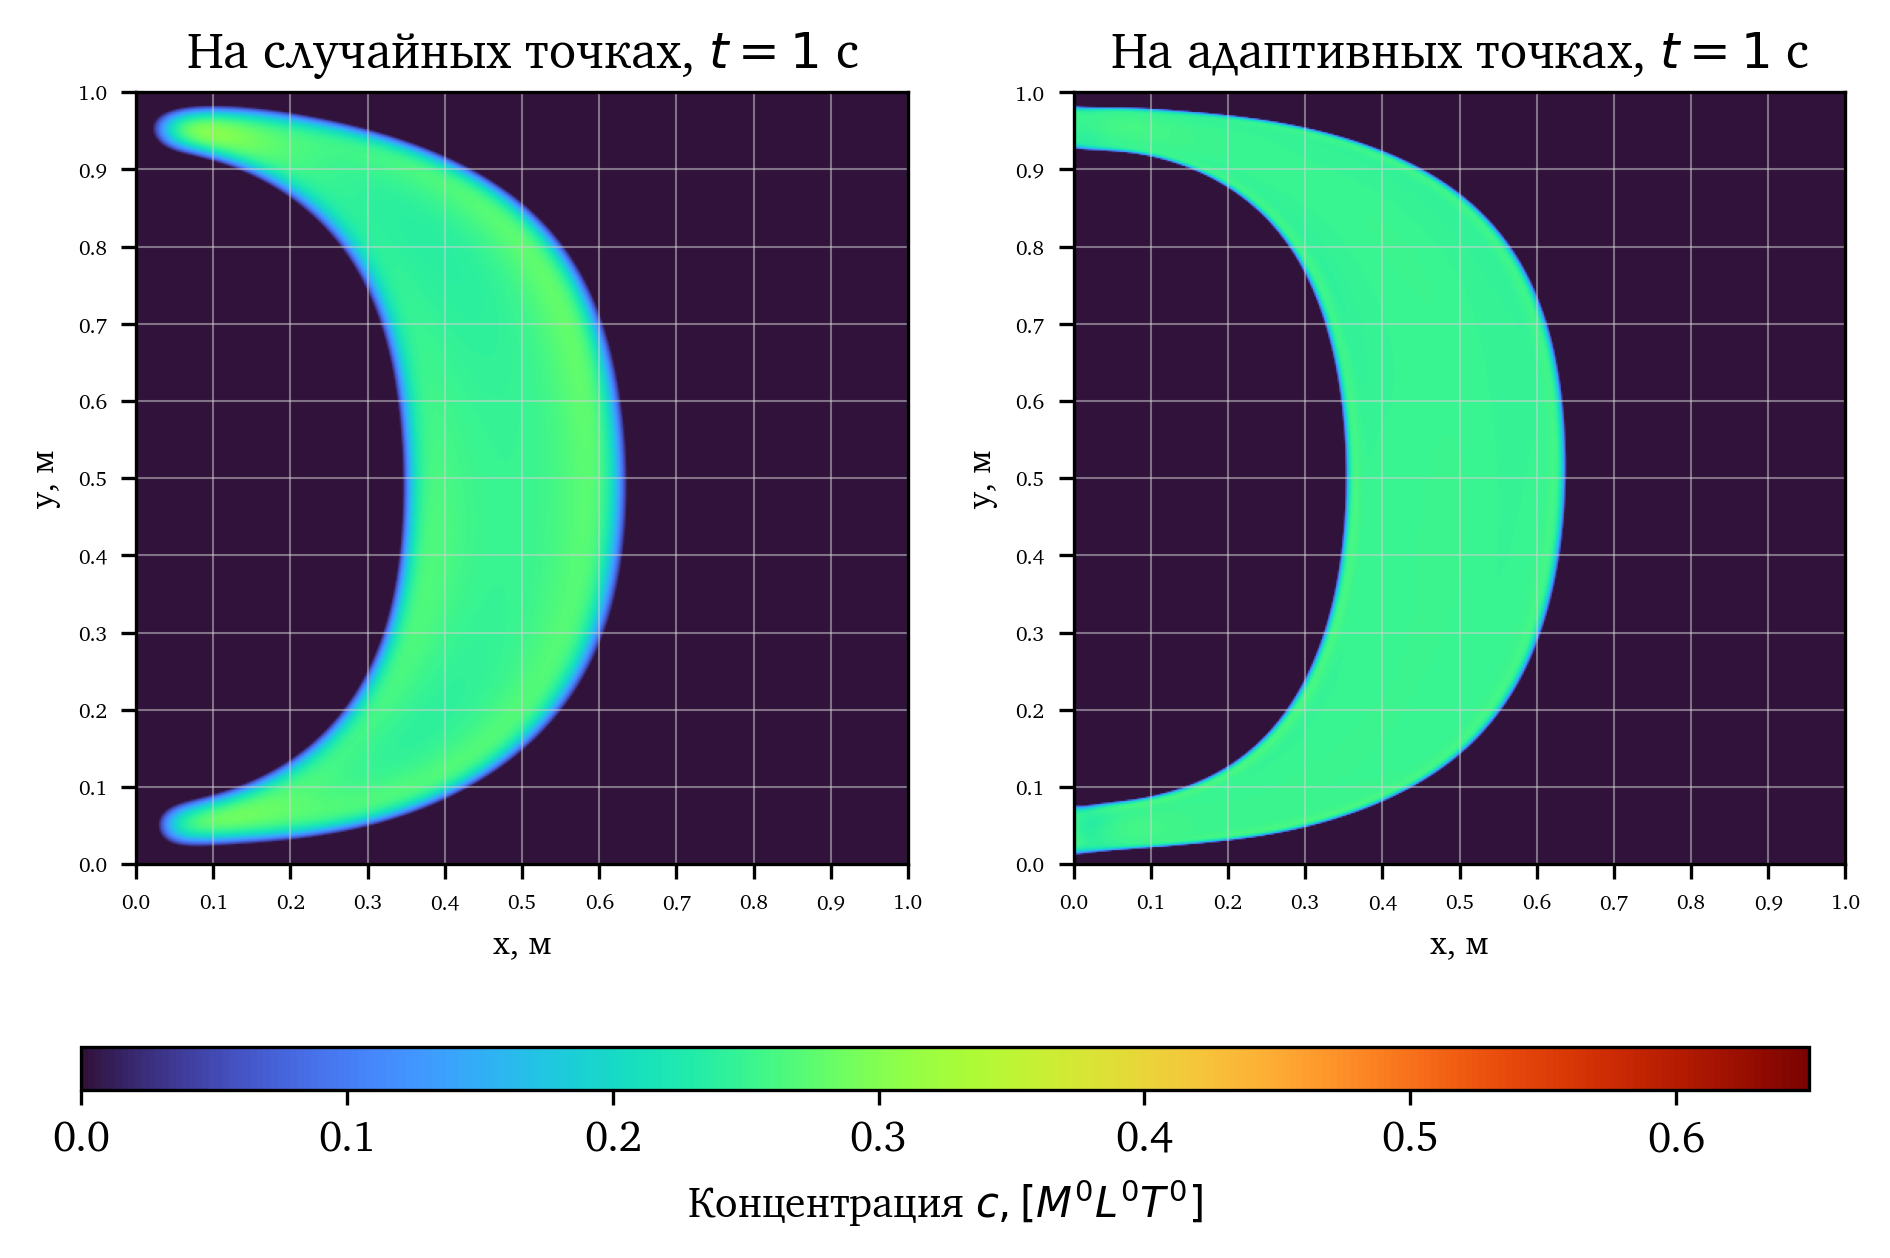

In [95]:
fig = plt.figure(dpi=300)
plt.subplot(121)
im1 = plt.imshow(c_for4[0][-1], cmap='turbo', extent=[0,1,1,0])
plt.xlabel('x, м', fontsize=8)
plt.ylabel('y, м', fontsize=8)
plt.xticks(np.arange(0, 1 + 0.1, 0.1))
plt.yticks(np.arange(0, 1 + 0.1, 0.1))
plt.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
plt.gca().invert_yaxis()
plt.clim([0, cmax])
plt.tick_params(axis='both', which='major', labelsize=5)
plt.title("На случайных точках, $t = 1$ с")

plt.subplot(122)
plt.imshow(c_for4[1][-1], cmap='turbo', extent=[0,1,1,0])
plt.xlabel('x, м', fontsize=8)
plt.ylabel('y, м', fontsize=8)
plt.xticks(np.arange(0, 1 + 0.1, 0.1))
plt.yticks(np.arange(0, 1 + 0.1, 0.1))
plt.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
plt.gca().invert_yaxis()
plt.clim([0, cmax])
plt.tick_params(axis='both', which='major', labelsize=5)
plt.title("На адаптивных точках, $t = 1$ с")

cbar_ax = fig.add_axes([0.05, 0.15, 0.9, 0.03])
fig.colorbar(im1, cax=cbar_ax, orientation='horizontal', label='Концентрация $c, [M^0L^0T^0]$')

plt.tight_layout(rect=[0, 0.15, 1, 1]) 

In [15]:
def plot_results(data,
                 N: int,
                 limits: list,
                 path: str = '',
                 cmaps: list = None,
                 title: list = None,
                 lims: list = None,
                 cbar_labels: list = None,
                 tick_step: float = 0.25
                 ):
    """
    Plots data from Neural Network

    Parameters:
    -----------
    data : list[np.ndarray]
        List of M arrays, each shaped (N, H, W)
    N : int
        Number of rows in the plot grid
    limits : list[float]
        Plotting area limits [x_min, x_max, y_min, y_max]
    path : str
        Path to save the figure
    cmaps : list[str]
        List of colormaps per column (length M)
    title : list[list[str]]
        Titles for each subplot, shape (M, N)
    lims : list[list[float]]
        List of [vmin, vmax] per column (length M)
    cbar_labels : list[str]
        Labels for colorbars (length M)
    tick_step : float
        Tick step on both axes
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    x_min, x_max, y_min, y_max = limits
    M = len(data)

    if cmaps is None:
        cmaps = ['turbo'] * M

    if cbar_labels is None:
        cbar_labels = [f'$f_{i}$' for i in range(1, M + 1)]

    if title is None:
        title = [[f'$f_{col}(x,y)$' for _ in range(N)] for col in range(M)]

    if lims is None:
        lims = [[np.min(data[col]), np.max(data[col])] for col in range(M)]

    height_ratios = []
    for i in range(2 * N - 1):
        if i % 2 == 0:
            height_ratios.append(1)
        elif i == 2 * N - 3:
            height_ratios.append(0.5 * N / (N + 1) + 0.5)
        else:
            height_ratios.append(0.5 * N / (N + 1))

    width_inches = M * 3
    height_inches = 3 * N + 0.5
    fig = plt.figure(figsize=(width_inches, height_inches), dpi=300)

    gs = gridspec.GridSpec(
        nrows=2 * N - 1,
        ncols=M,
        height_ratios=height_ratios,
        hspace=0.0,
        wspace=0.4
    )

    im_list = []
    axes = [[None] * M for _ in range(N)]

    for row in range(N):
        for col in range(M):
            ax = fig.add_subplot(gs[row * 2, col])
            im = ax.imshow(data[col][row], cmap=cmaps[col],
                           vmin=lims[col][0], vmax=lims[col][1],
                           extent=[x_min, x_max, y_max, y_min])
            ax.set_title(title[col][row], fontsize=9, pad=6)
            ax.invert_yaxis()
            ax.set_xlabel('x, м', fontsize=8)
            ax.set_ylabel('y, м', fontsize=8)
            ax.set_xticks(np.arange(x_min, x_max + tick_step, tick_step))
            ax.set_yticks(np.arange(y_min, y_max + tick_step, tick_step))
            ax.tick_params(axis='both', which='major', labelsize=5)
            ax.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
            axes[row][col] = ax
            im_list.append(im)

    for col in range(M):
        ax_last = axes[N - 1][col]
        ax_prev = axes[N - 2][col]

        pos_last = ax_last.get_position()
        pos_prev = ax_prev.get_position()

        center_y = (pos_last.y0 + pos_prev.y1) / 2
        height = 0.012

        cax = fig.add_axes([pos_last.x0, center_y - height / 2, pos_last.width, height])
        cbar = fig.colorbar(im_list[(N - 1) * M + col], cax=cax, orientation='horizontal')
        cax.set_xlabel(cbar_labels[col], fontsize=8, labelpad=2)
        cax.tick_params(labelsize=6)

    plt.show()

    if path:
        fig.savefig(path, bbox_inches='tight')

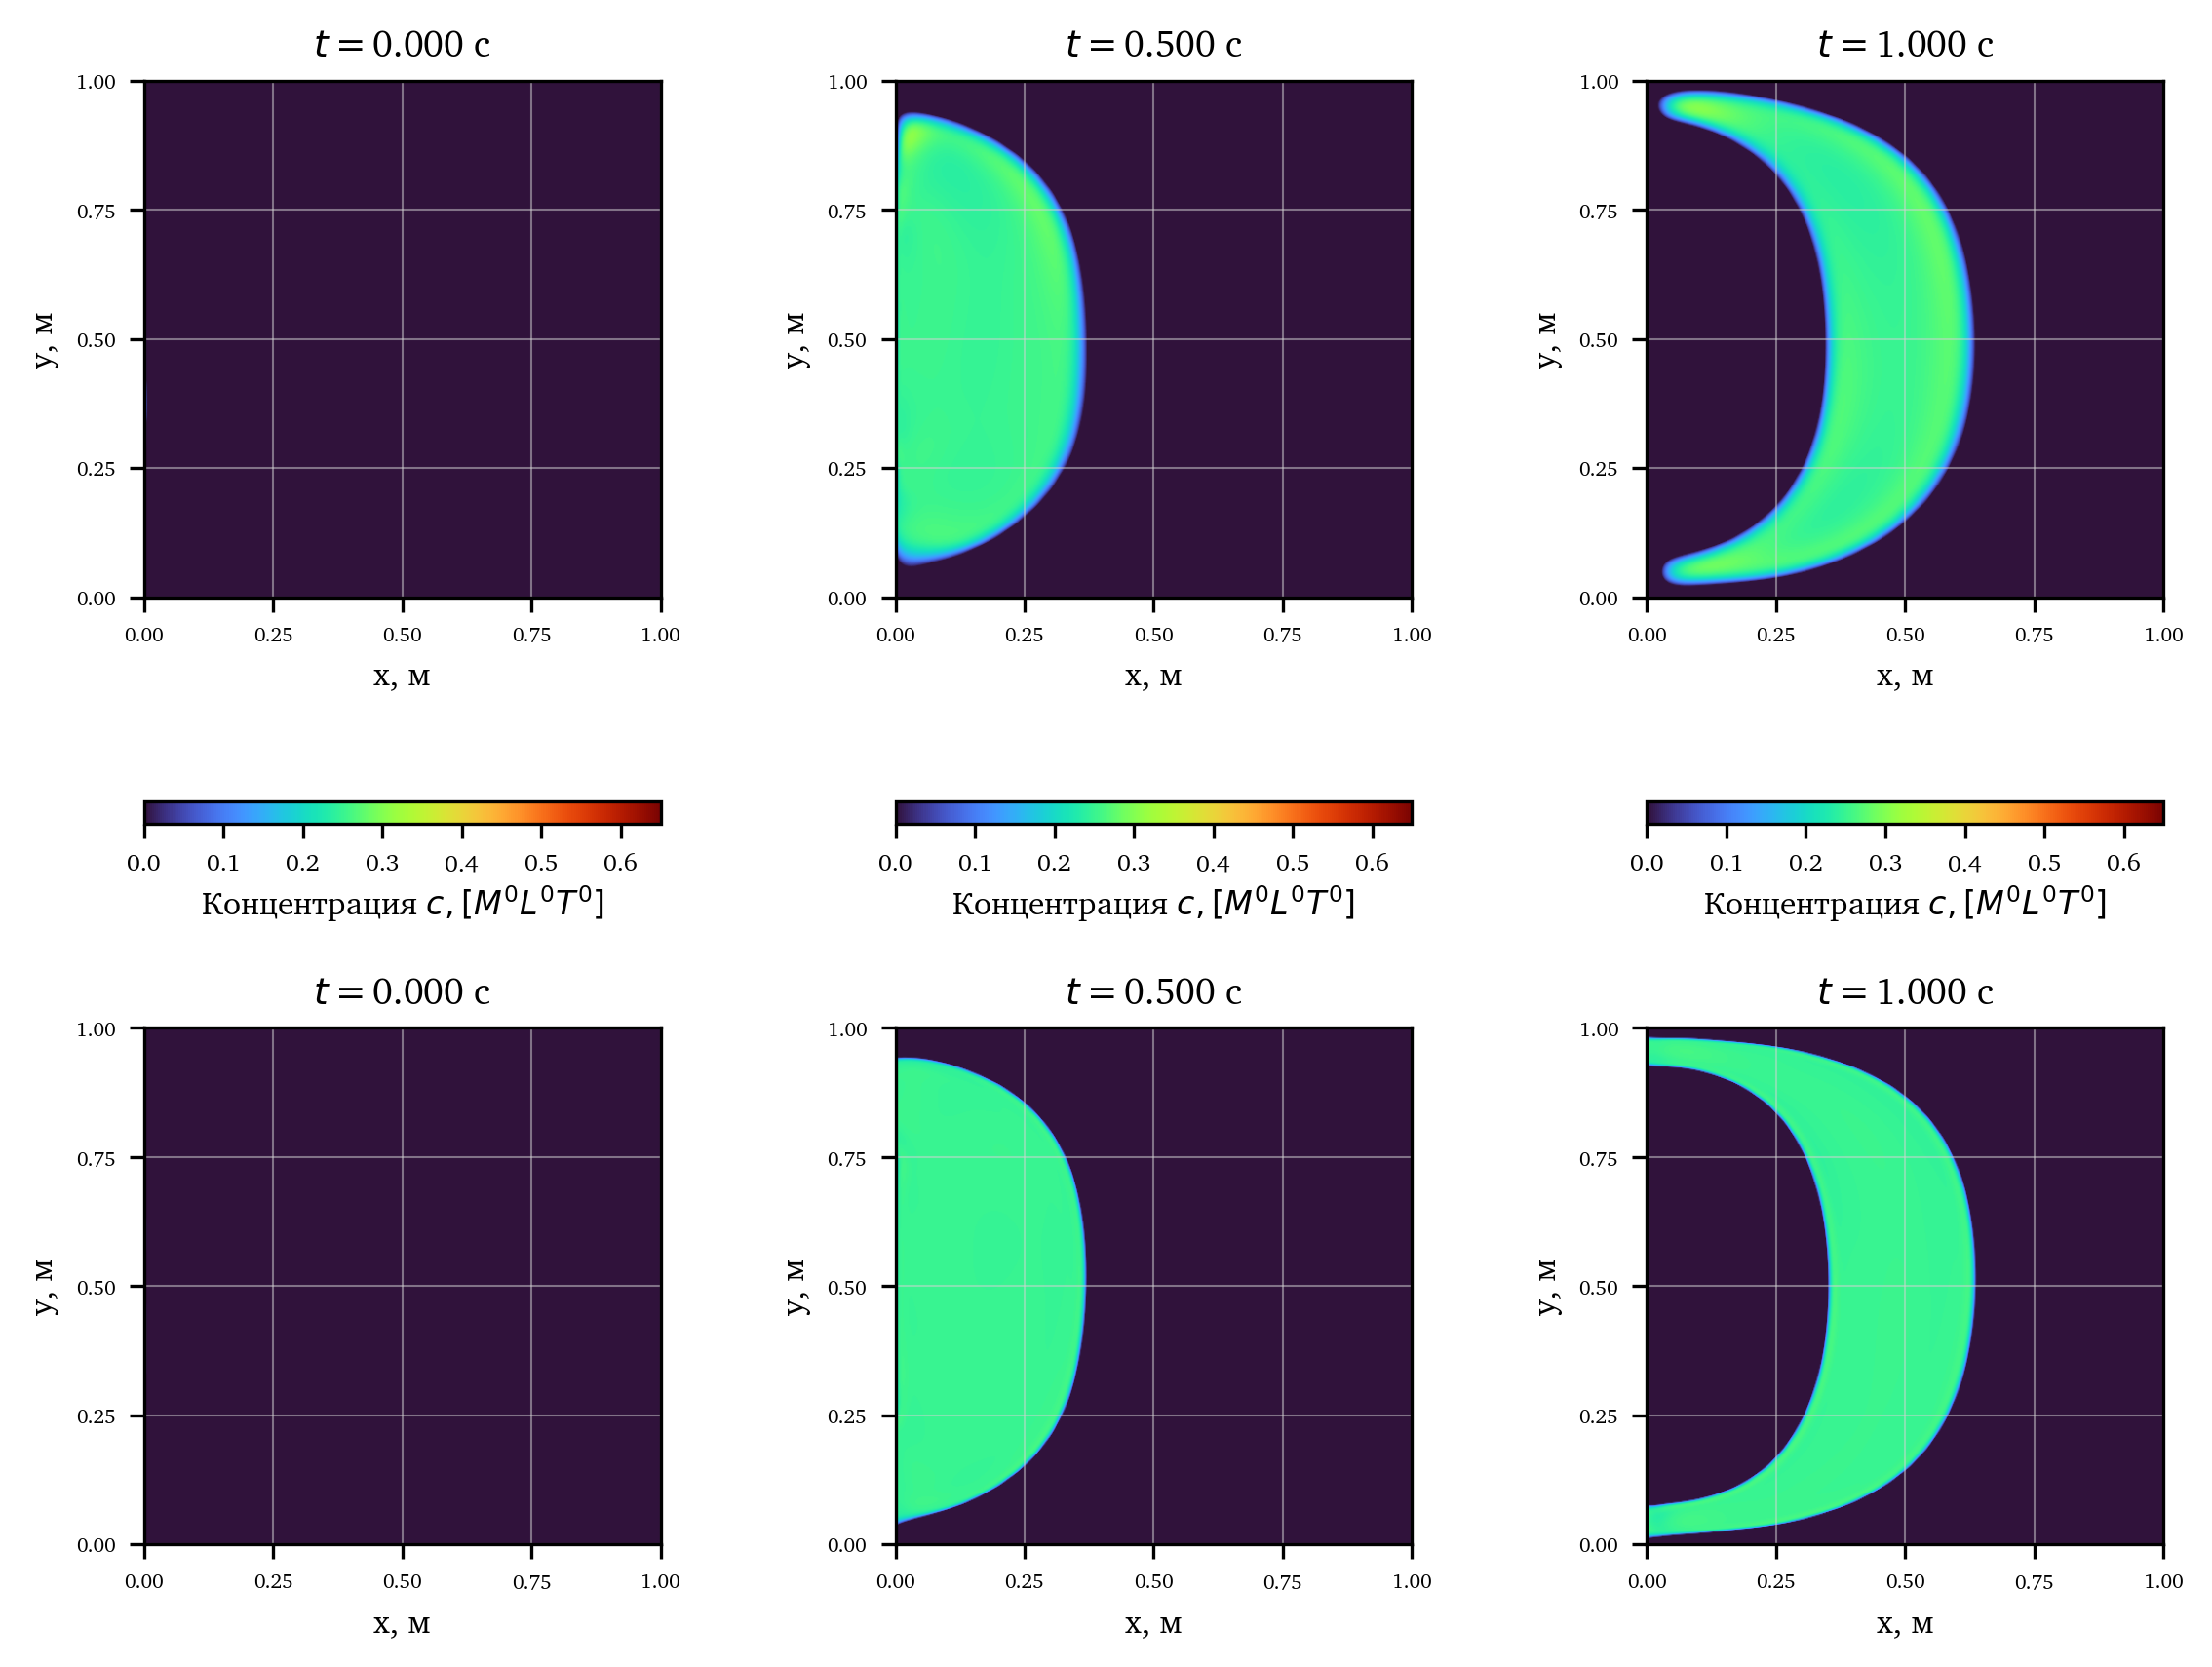

(3, 4)

In [26]:
data = [cfor4[0], cfor4[1], cfor4[2]]
lims = [[0,cmax], [0,cmax], [0,cmax]]
labels = ['Концентрация $c, [M^0L^0T^0]$', 'Концентрация $c, [M^0L^0T^0]$', 'Концентрация $c, [M^0L^0T^0]$']
titles = np.array([[f'$t=${i:.3f} с' for i in t_for4]]*4).T
plot_results(data=data, N=len(data[0]), limits=[0, L, 0, H], title=titles, cmaps=['turbo','turbo','turbo'], lims=lims, cbar_labels=labels, path='pictures/zerobeta0123')
pass
titles.shape

100%|██████████| 1000/1000 [09:36<00:00,  1.73it/s]


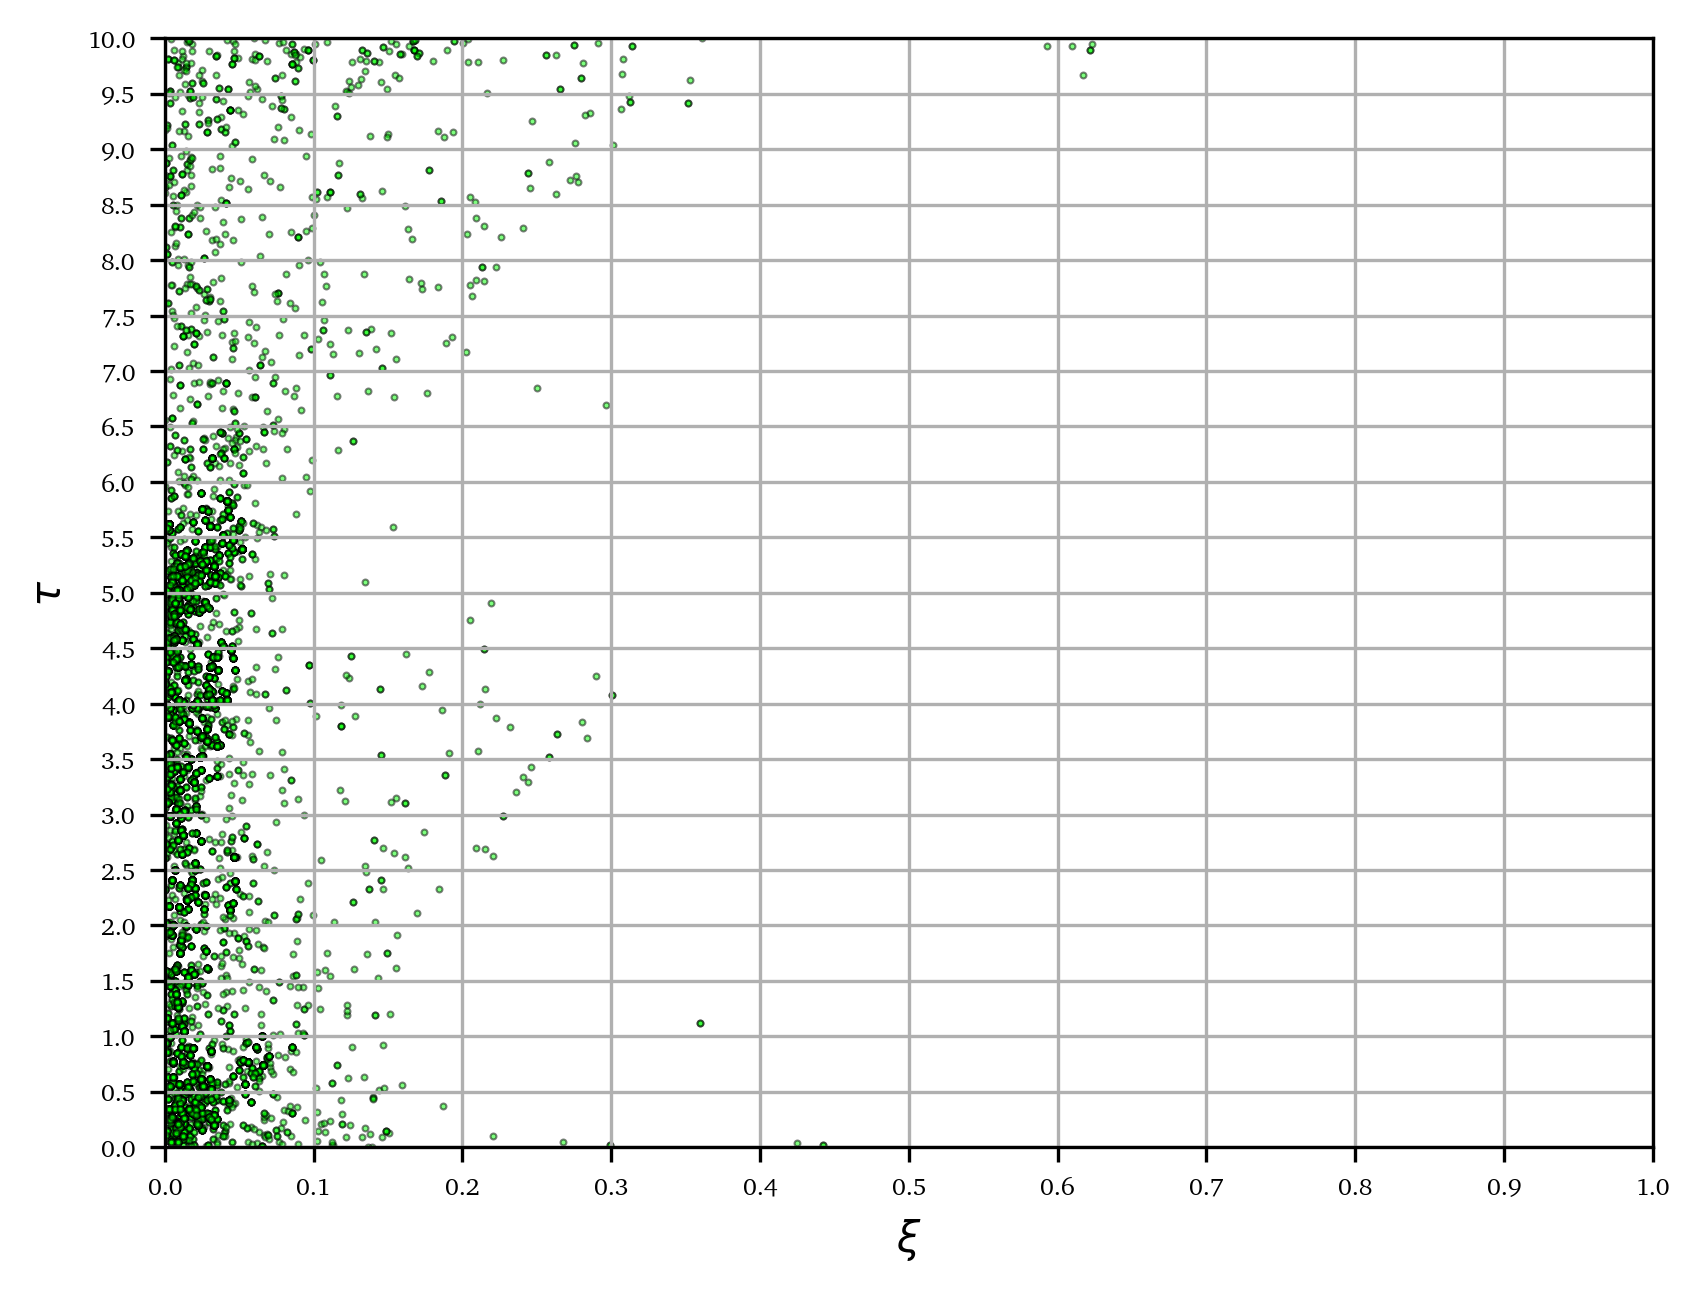

In [61]:
net = nets[0]
for _ in tqdm(range(1000)): net.make_distributed_points()
plt.figure(dpi=300)
plt.scatter(net.x_PDE[net.N_PDE**3:].data.cpu(), net.t_PDE[net.N_PDE**3:].data.cpu(), alpha=0.5, c='lime', edgecolors='black', s=2, linewidths=0.5)
plt.grid()
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\tau$')
plt.xlim(0,L)
plt.ylim(0,net.T*net.t_max)
plt.tick_params(axis='both', which='major', labelsize=6)
plt.yticks(np.arange(0,net.T*net.t_max+0.1,0.5))
plt.xticks(np.arange(0,L+0.1,0.1))
pass

MAE for 0: 0.0048514207422881575
MAE for 1: 0.008692932837823433
MAE for 2: 0.011936444059681537
MAE for 3: 0.004917843668392639


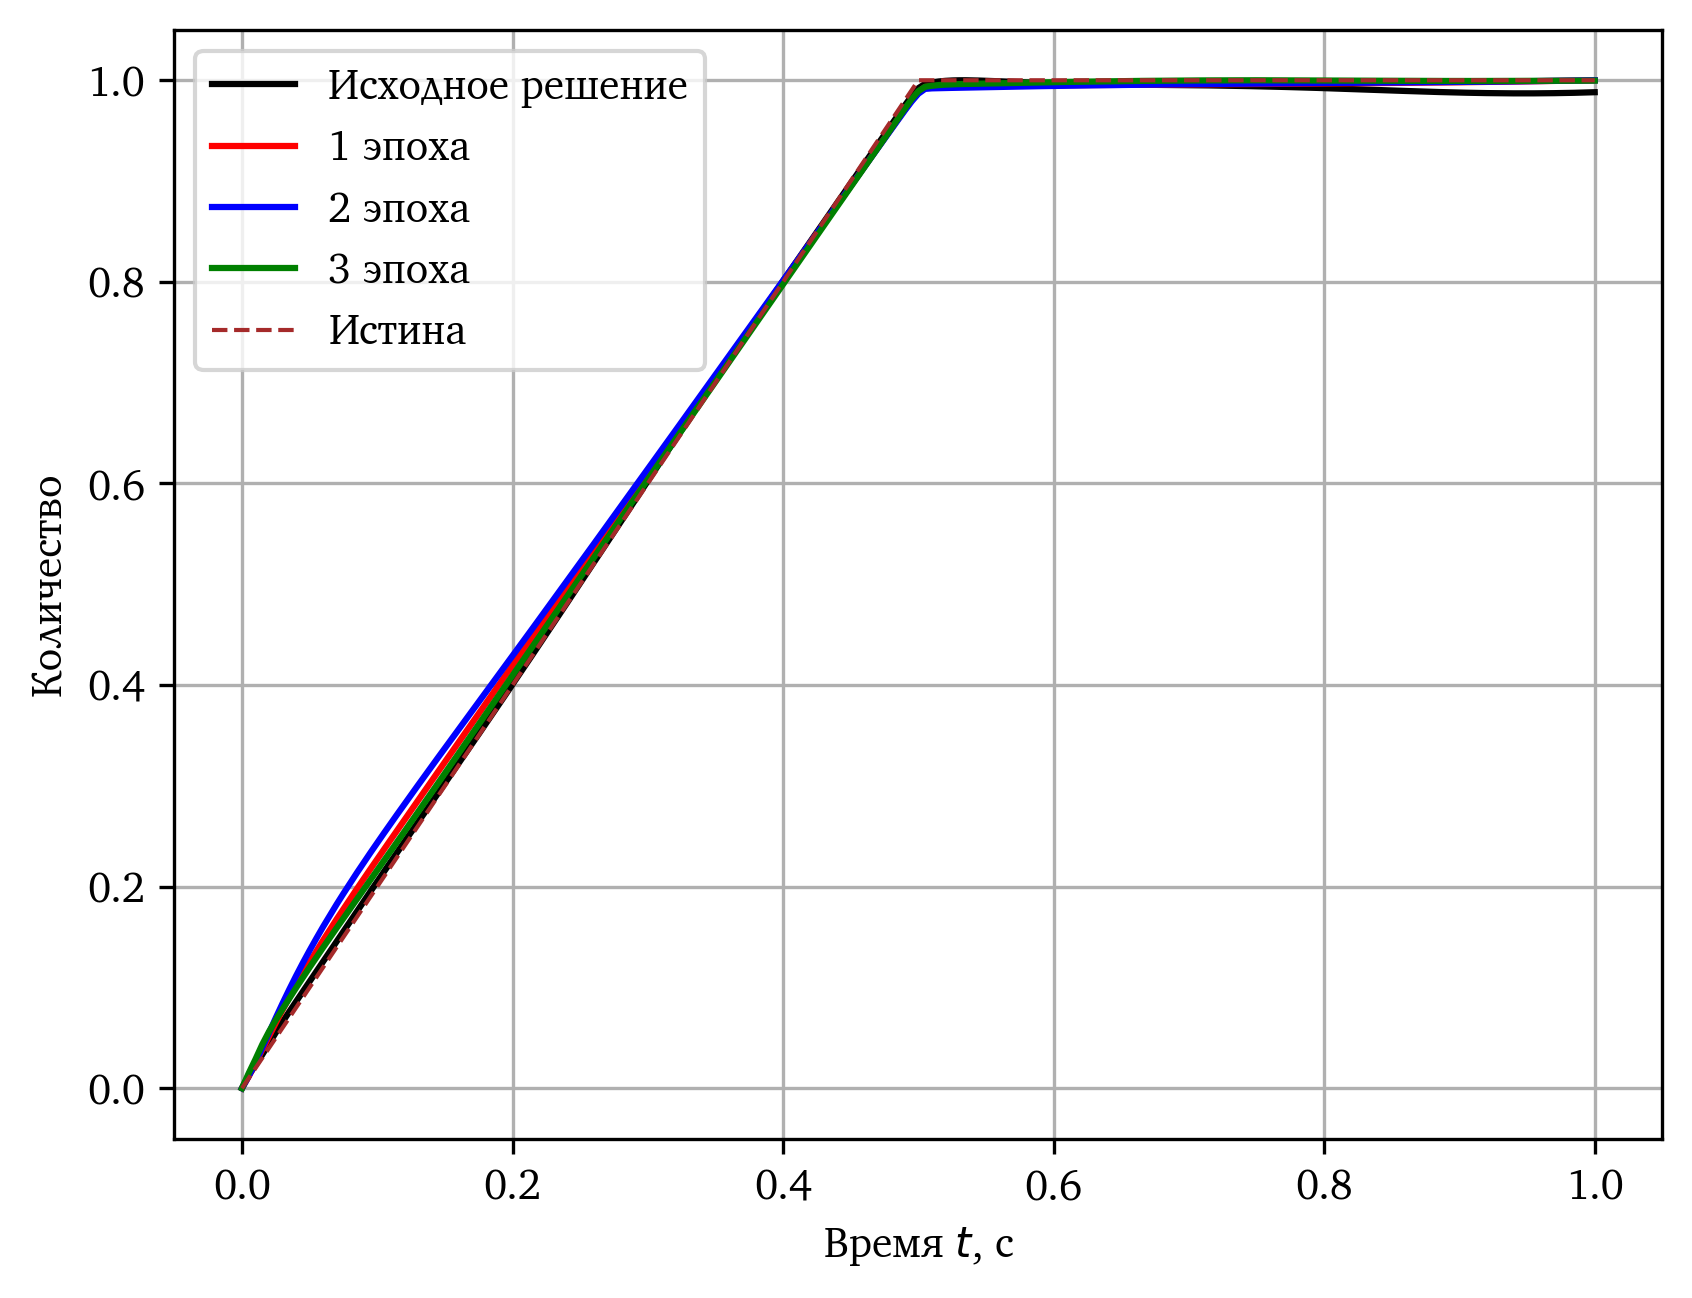

In [82]:
ttrue = np.zeros_like(t_for4)
times = [0] + net.times + [t_for4[-1]]
a = []
for i in range(1, len(net.c_cond)+1):
    ttrue = np.where((t_for4<=times[i]) & (t_for4>times[i-1]), net.c_cond[i-1]*(t_for4 - times[i-1])*np.sum(u_in*np.ones_like(y))*dy+np.sum(a)*np.sum(u_in*np.ones_like(y))*(times[i] - times[i-1])*dy, ttrue)
    if net.c_cond[i-1]==0:
        a.append(net.c_cond[i-2])
        ttrue =  np.where((t_for4<=times[i]) & (t_for4>times[i-1]), np.sum(a)*np.sum(u_in*np.ones_like(y))*(times[i-1] - times[i-2])*dy, ttrue)
sums = []
for i in range(4):
    ss = []
    for j in c_for4[i]:
        ss.append(np.sum(j)*dy)
    sums.append(ss)
plt.figure(dpi=300)
plt.grid()

colors = ['black', 'red', 'blue', 'green']
labels = ['Исходное решение', '1 эпоха', '2 эпоха', '3 эпоха']
for i in range(4):
    sums[i] = (sums[i] - np.min(sums[i])) / (np.max(sums[i]) - np.min(sums[i]))
    plt.plot(t_for4, sums[i], label=labels[i], c=colors[i])
ttrue /= np.max(ttrue)
plt.plot(t_for4, ttrue, c='brown', linewidth=1, ls='--', label='Истина')
plt.legend()
plt.xlabel('Время $t$, с')
plt.ylabel('Количество')

for i in range(4):
    print (f'MAE for {i}: {np.sum(np.abs(sums[i] - ttrue))/len(t_for4)}')
pass

In [57]:
netgamma = []
path1 = ['data/neural/gamma1', 'data/neural/beta0.0 chi0.5 cin0.25 t1 (0)']

for i in range(2):
    netgamma.append(Poisson_Convection.load(path1[i], device=device, loadloss=False))
c_for2 = []
t_Tensor = torch.linspace(0, net.t_max, 3)
t_for2 = np.linspace(0, net.t_max, 3)

for net in netgamma:
    ci = []
    for i in tqdm(t_Tensor):
        mesh_XYT = torch.stack(torch.meshgrid(x_Tensor,y_Tensor,i, indexing='ij')).reshape(3, -1).T
        XX = torch.autograd.Variable(mesh_XYT[:,0], requires_grad=True)
        YY = torch.autograd.Variable(mesh_XYT[:,1], requires_grad=True)
        TT = torch.autograd.Variable(mesh_XYT[:,2], requires_grad=True)
        BETA = torch.autograd.Variable(net.beta*torch.ones_like(XX), requires_grad=True)
        ci.append(net.get_c(XX,YY,TT, BETA).reshape(Nx, Ny).transpose(1,0))
    c_for2.append(ci)
cfor2 = np.array(c_for2).transpose(1,0,2,3) * cmax

100%|██████████| 3/3 [00:00<00:00,  8.29it/s]


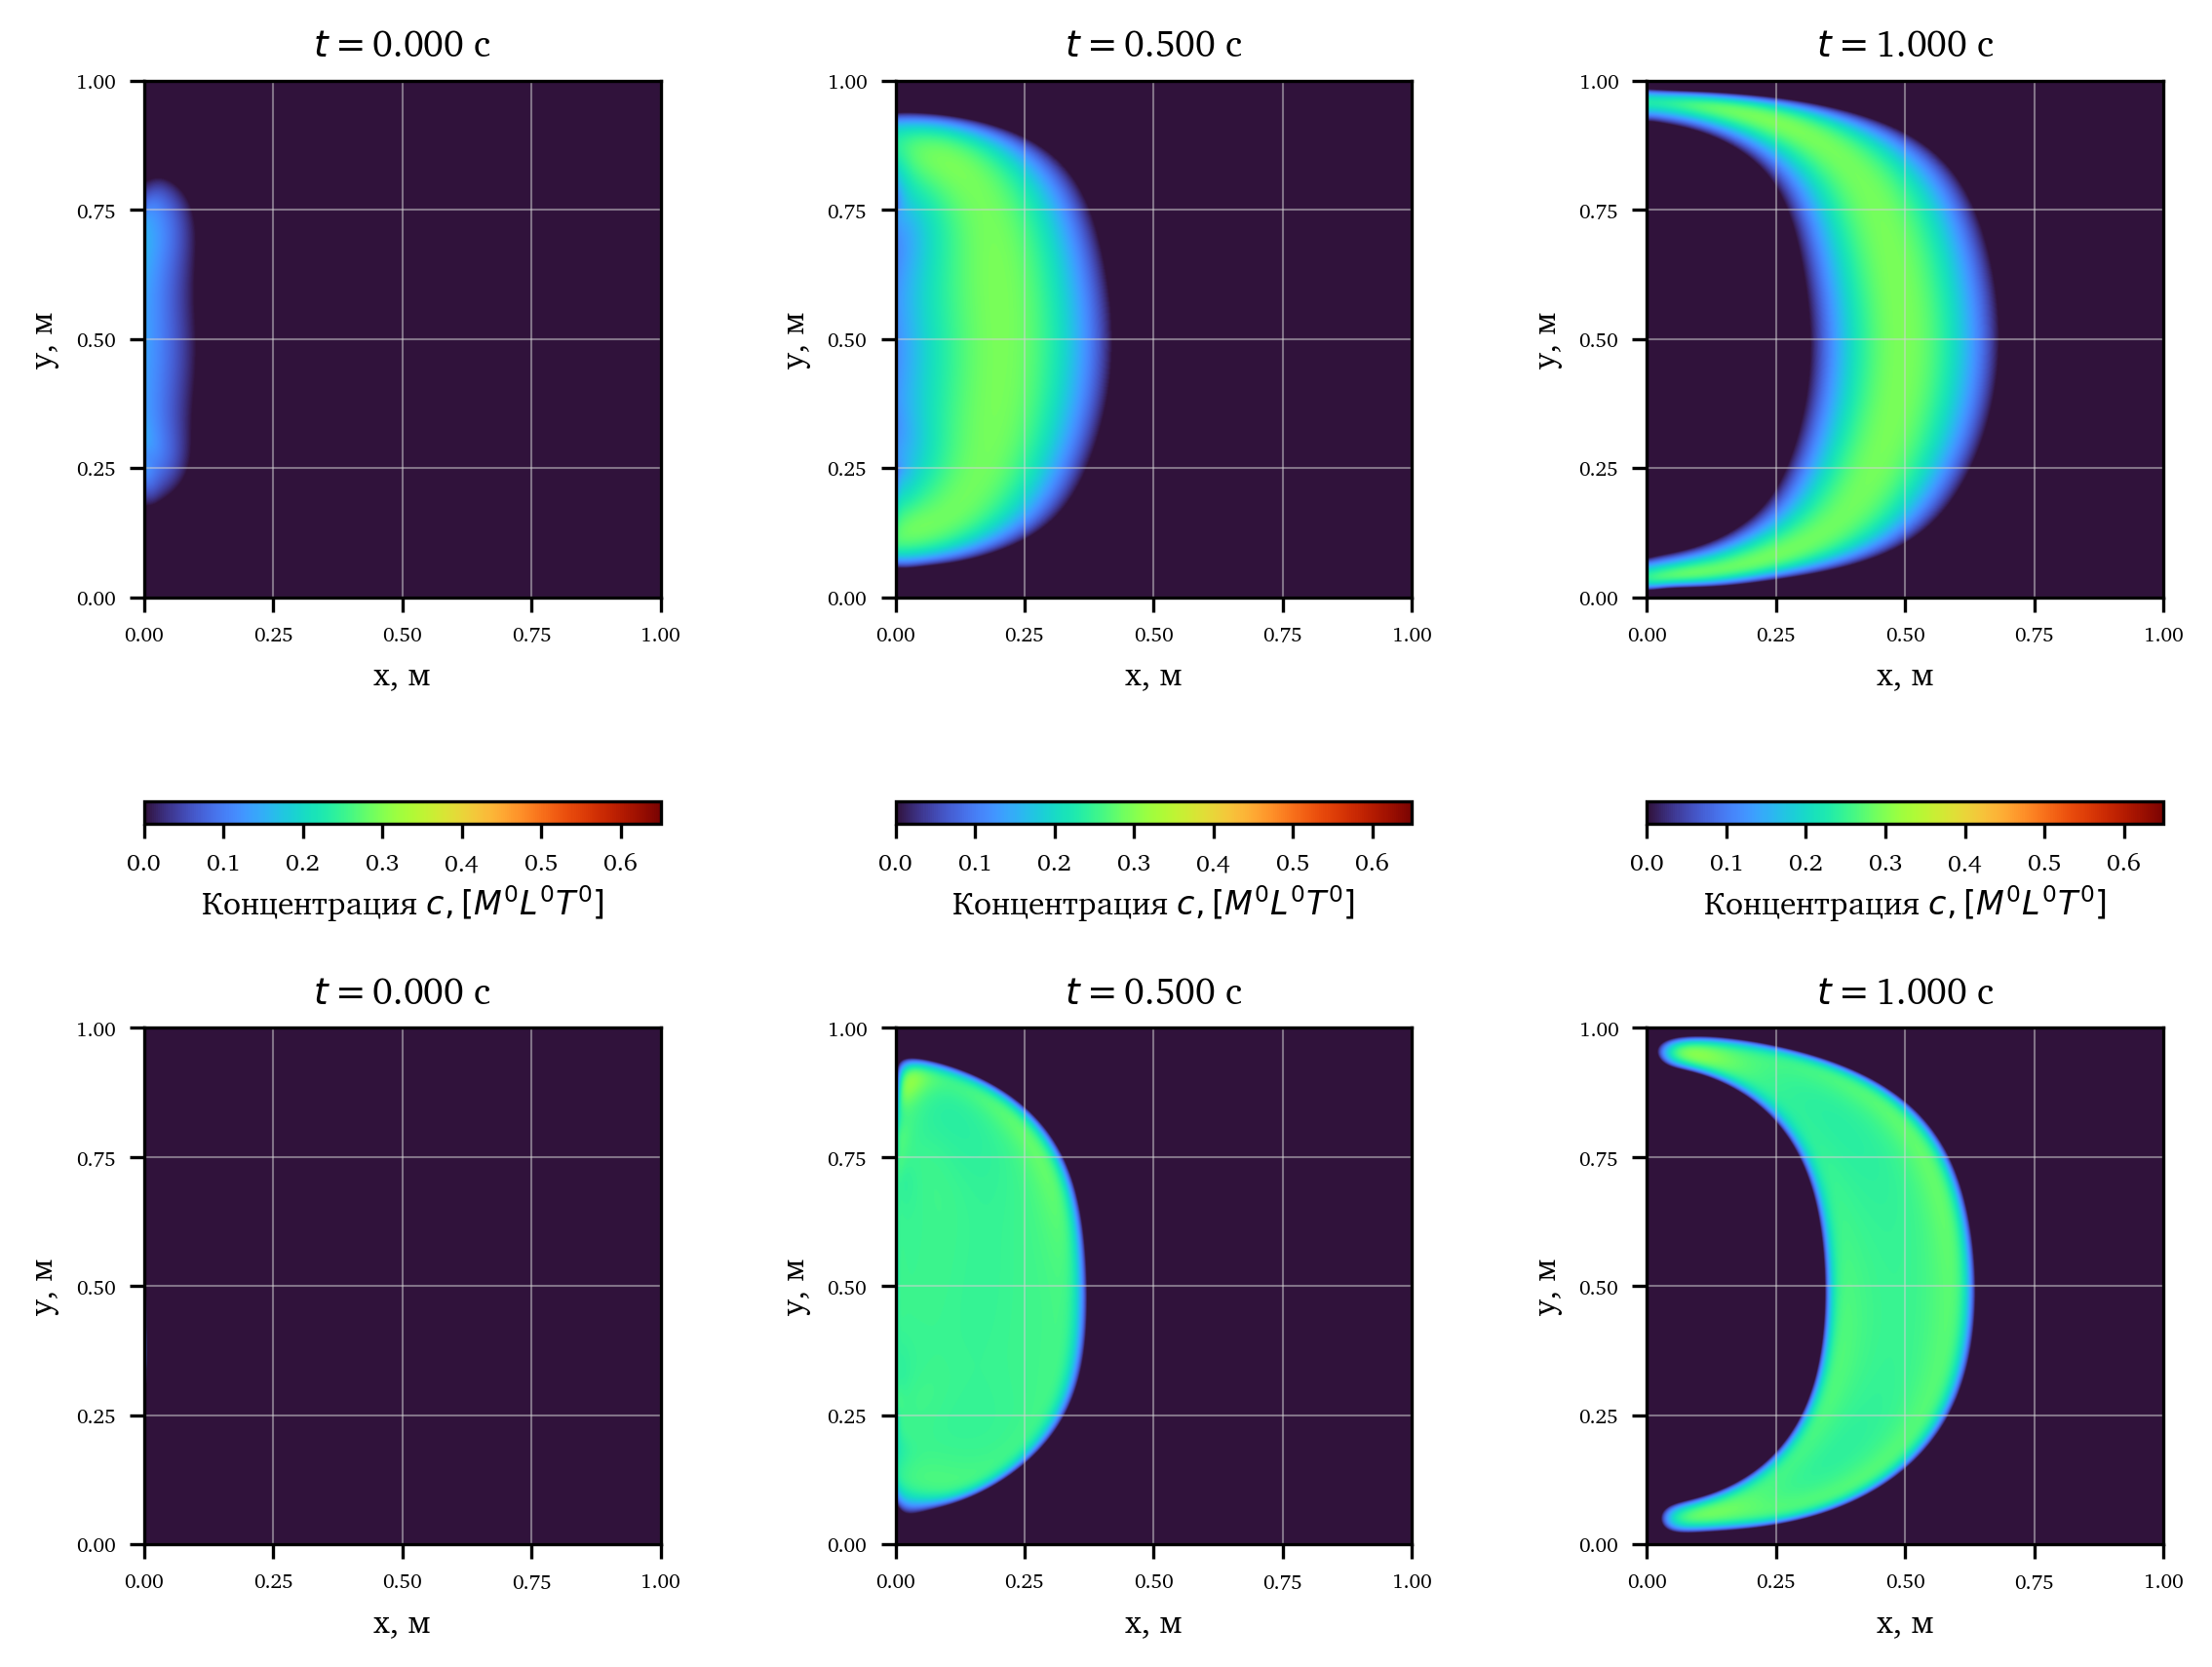

(3, 4)

In [59]:
data = [cfor2[0], cfor2[1], cfor2[2]]
lims = [[0,cmax], [0,cmax], [0,cmax]]
labels = ['Концентрация $c, [M^0L^0T^0]$', 'Концентрация $c, [M^0L^0T^0]$', 'Концентрация $c, [M^0L^0T^0]$']
titles = np.array([[f'$t=${i:.3f} с' for i in t_for4]]*4).T
plot_results(data=data, N=len(data[0]), limits=[0, L, 0, H], title=titles, cmaps=['turbo','turbo','turbo'], lims=lims, cbar_labels=labels, path='pictures/zerobeta0123')
pass
titles.shape

(np.float64(0.06294135404129193),
 np.float32(0.047200065),
 np.float64(0.015741288935138445))

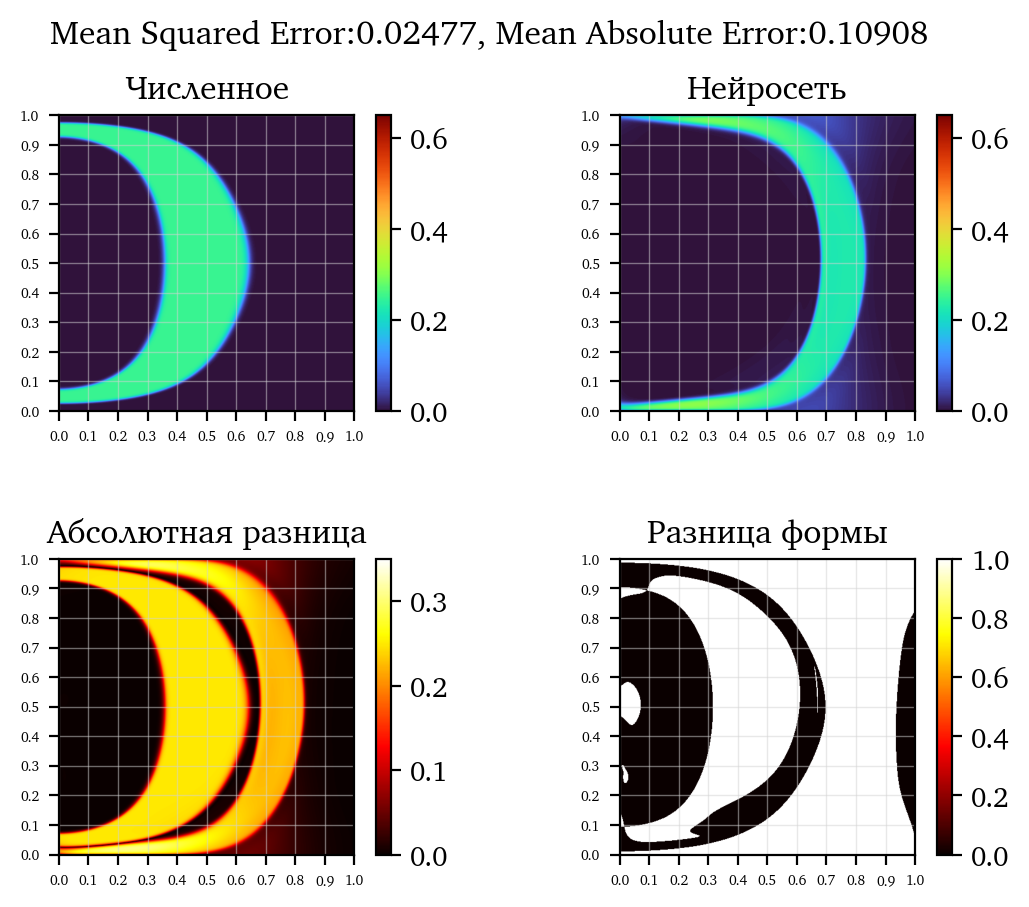

In [23]:
c_true = solver.Q[-1]
c_pred = c[-1]

MSE = np.mean((c_pred - c_true)**2)
MAE = np.mean(np.abs(c_pred - c_true))

fig = plt.figure(dpi=200)
plt.suptitle(f'Mean Squared Error:{MSE:.5f}, Mean Absolute Error:{MAE:.5f}')
plt.subplots_adjust(hspace=0.5, wspace=0.3)

plt.subplot(221)
plt.title('Численное')
plt.imshow(c_true, cmap='turbo', extent=[0,1,1,0])
plt.colorbar()
plt.clim(0, solver.cmax)
plt.tick_params(axis='both', labelsize=5)
plt.yticks(np.arange(0,1.1,0.1))
plt.xticks(np.arange(0,1.1,0.1))
plt.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
plt.gca().invert_yaxis()

plt.subplot(222)
plt.title('Нейросеть')
plt.imshow(c_pred, cmap='turbo', extent=[0,1,1,0])
plt.colorbar()
plt.clim(0, solver.cmax)
plt.tick_params(axis='both', labelsize=5)
plt.yticks(np.arange(0,1.1,0.1))
plt.xticks(np.arange(0,1.1,0.1))
plt.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
plt.gca().invert_yaxis()

plt.subplot(223)
plt.title('Абсолютная разница')
plt.imshow(np.abs(c_true - c_pred), cmap='hot', extent=[0,1,1,0])
plt.colorbar()
plt.clim(0, 0.35)
plt.tick_params(axis='both', labelsize=5)
plt.yticks(np.arange(0,1.1,0.1))
plt.xticks(np.arange(0,1.1,0.1))
plt.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
plt.gca().invert_yaxis()

plt.subplot(224)
plt.title('Разница формы')
plt.imshow(np.abs(np.where(np.abs(c_true)>1e-5, 1, 0) - np.where(np.abs(c_pred)>1e-3, 1, 0)), cmap='hot', extent=[0,1,1,0])
plt.colorbar()
plt.clim(0,1)
plt.tick_params(axis='both', labelsize=5)
plt.yticks(np.arange(0,1.1,0.1))
plt.xticks(np.arange(0,1.1,0.1))
plt.grid(color='lightgrey', alpha=0.5, linewidth=0.5)
plt.gca().invert_yaxis()
np.sum(c_true)*solver.dx*solver.dy, np.sum(c_pred)*solver.dx*solver.dy, np.sum(c_true)*solver.dx*solver.dy - np.sum(c_pred)*solver.dx*solver.dy

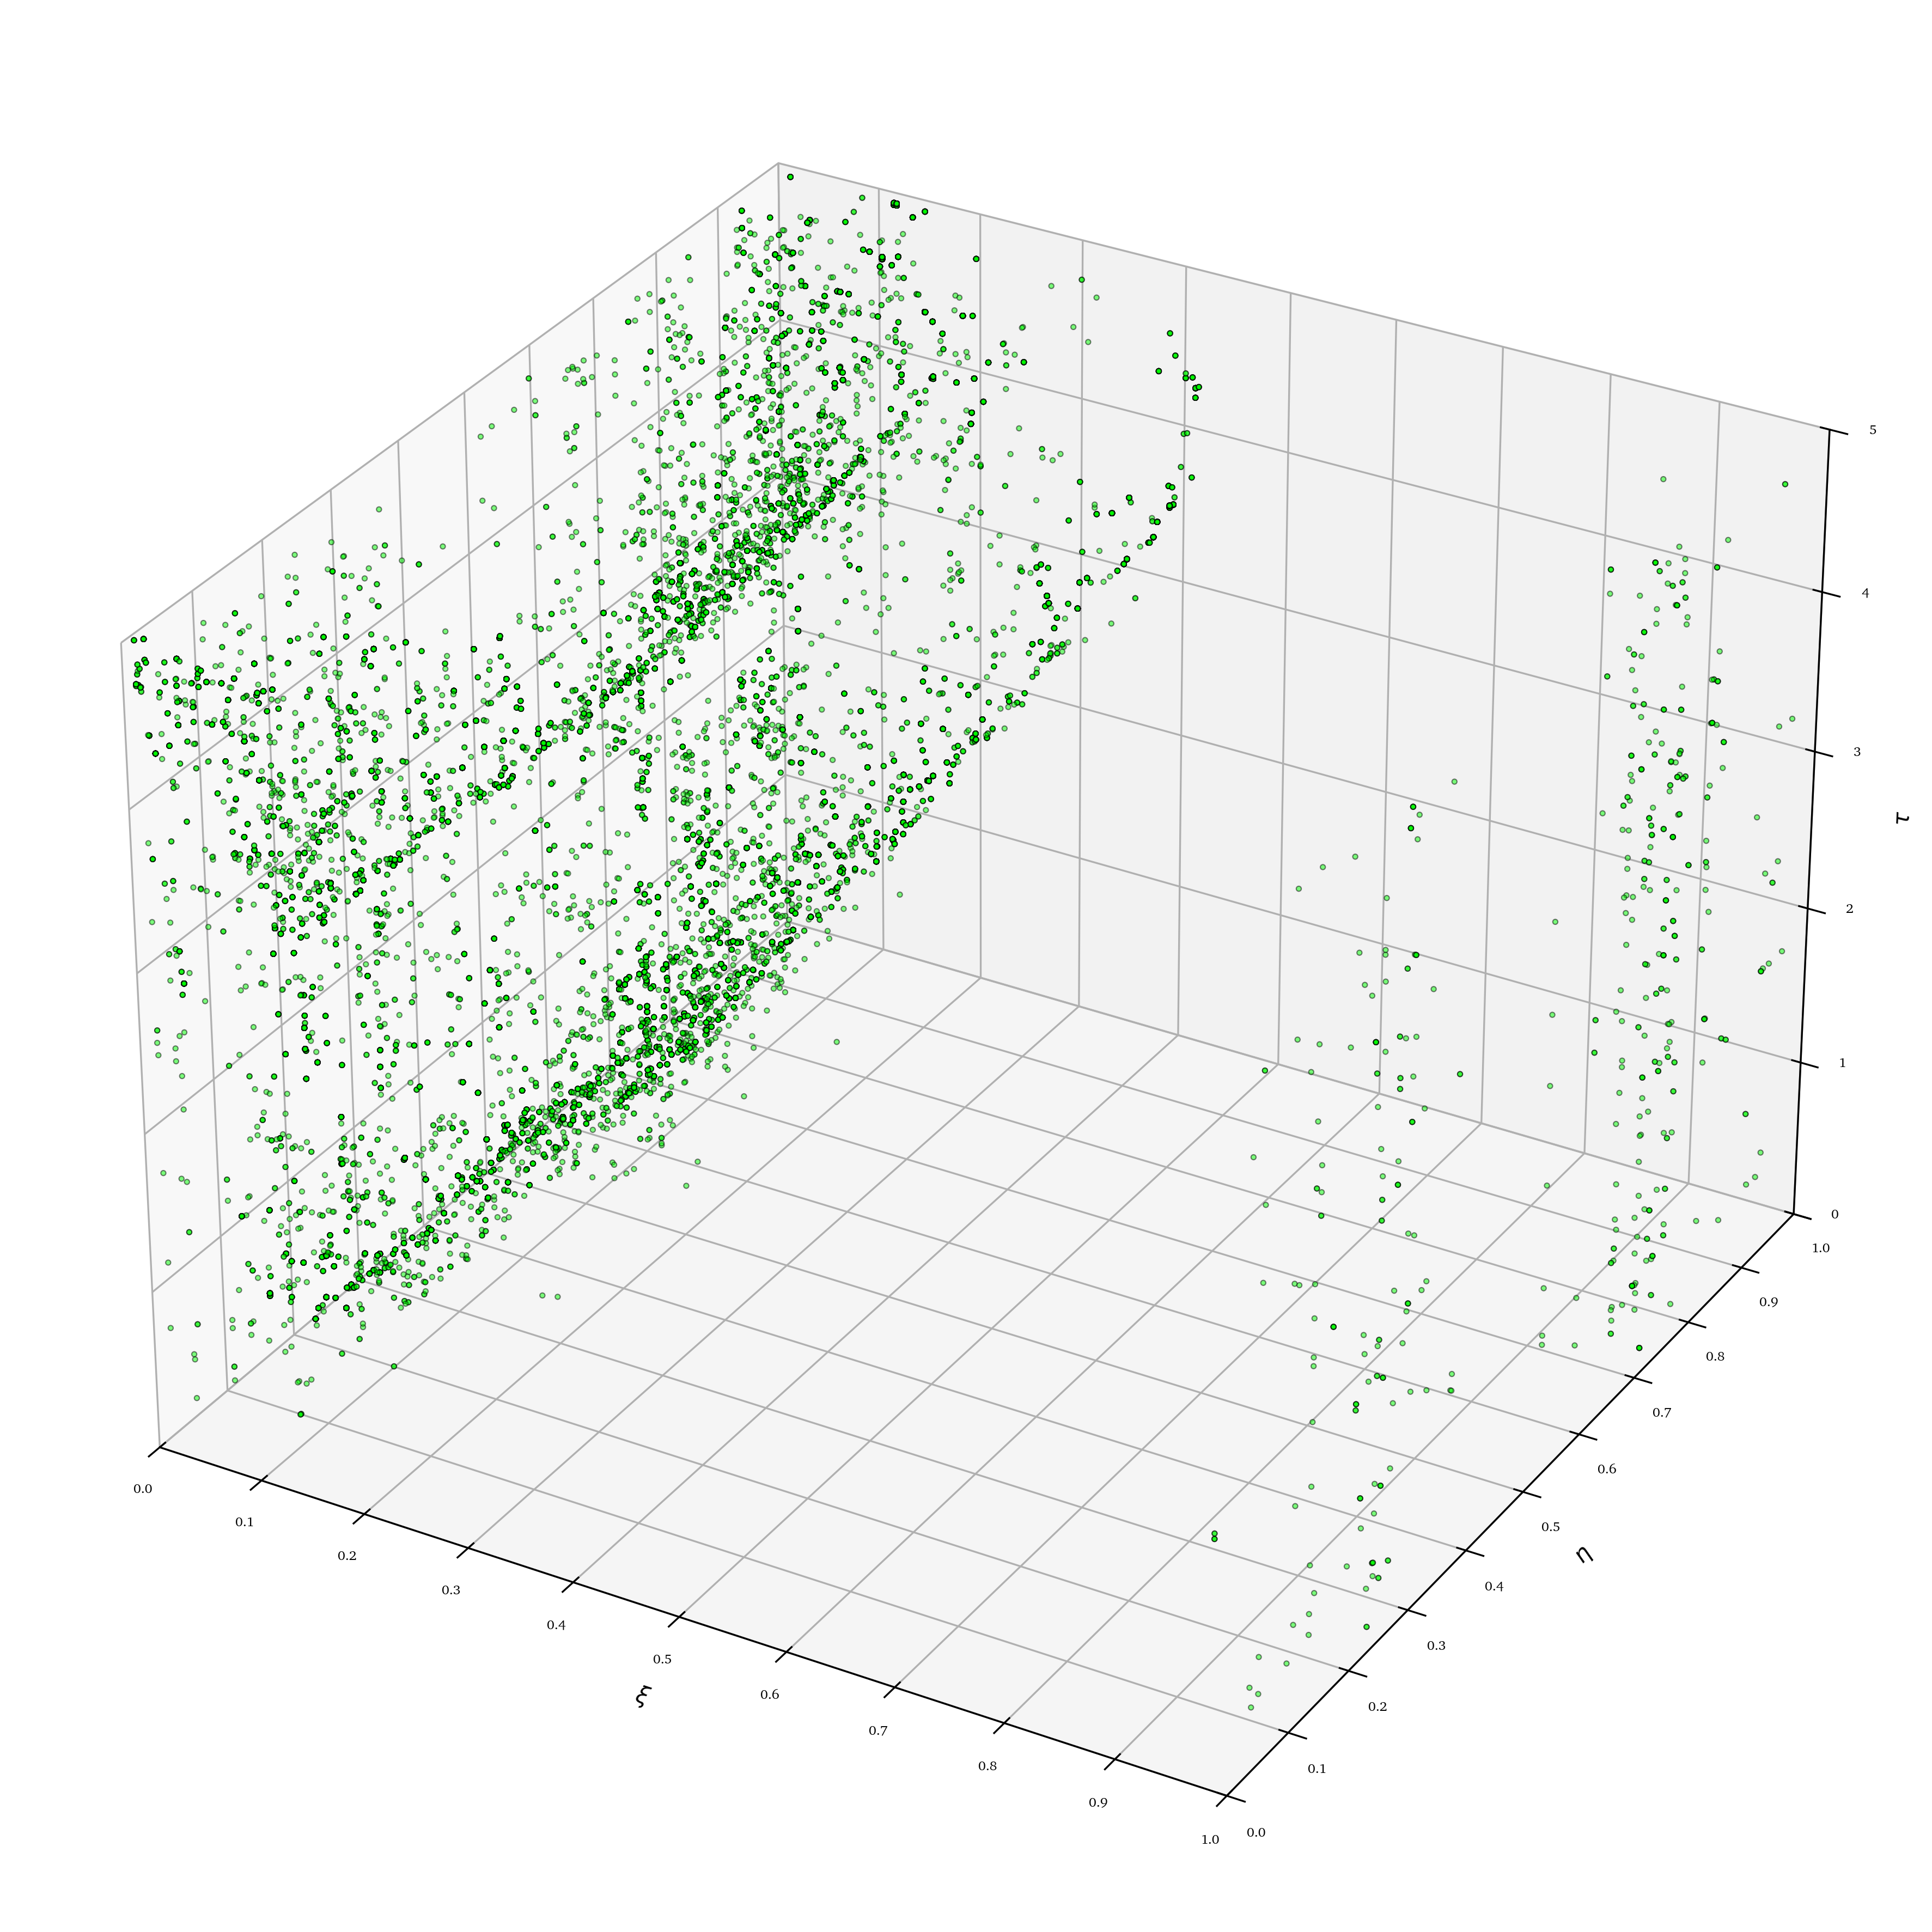

In [25]:
fig = plt.figure(figsize=(15,200),dpi=300)
ax = fig.add_subplot(111, projection='3d')
dots = ax.scatter(net.x_PDE[net.N_PDE**3:].data.cpu(), net.y_PDE[net.N_PDE**3:].data.cpu(), net.t_PDE[net.N_PDE**3:].data.cpu(), alpha=0.5, c='lime', edgecolors='black', s=5, linewidths=0.5)
ax.set_xlabel(r'$\xi$')
ax.set_ylabel(r'$\eta$')
ax.set_zlabel(r'$\tau$')
ax.set_xlim(0,L)
ax.tick_params(axis='both', which='major', labelsize=6)
ax.set_yticks(np.arange(0,1.1,0.1))
ax.set_xticks(np.arange(0,1.1,0.1))

ax.set_ylim(0,H)
ax.set_zlim(0,net.T)
pass

(0.0, 2.0)

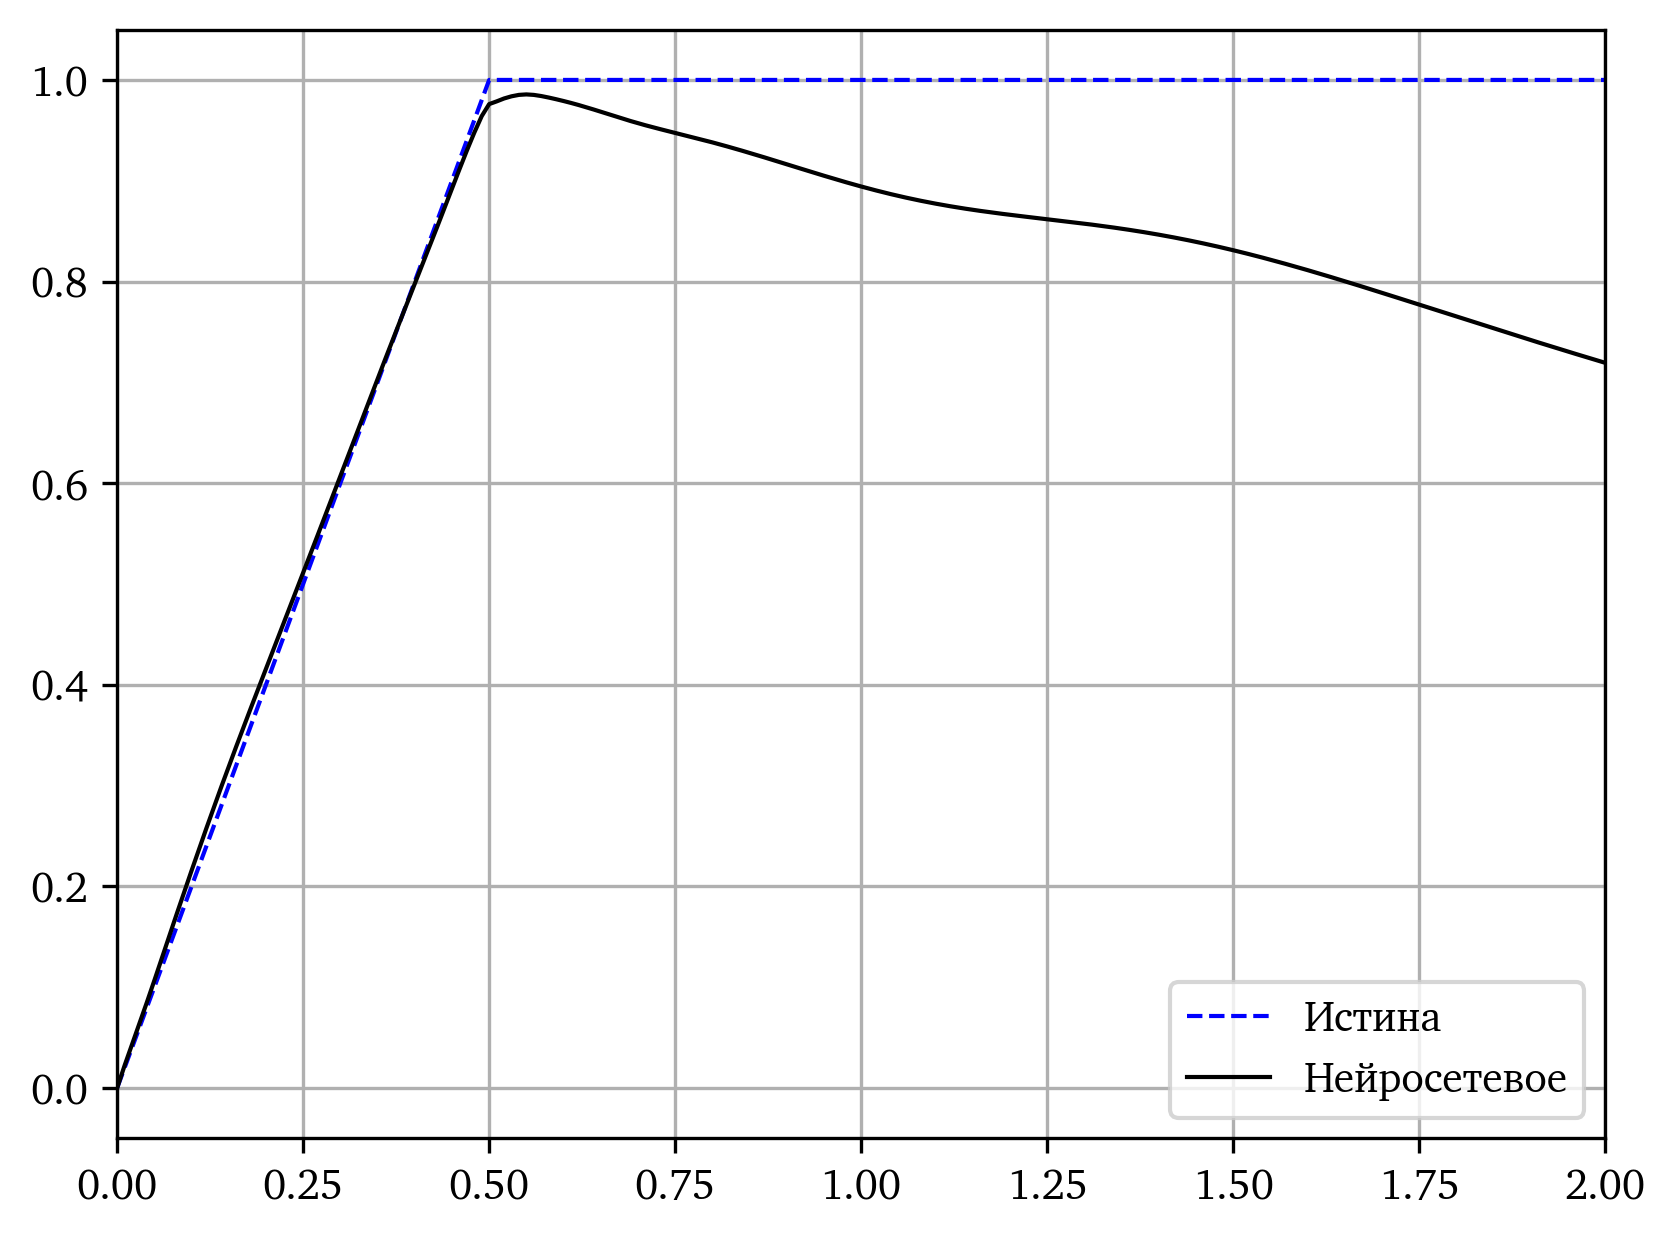

In [8]:
# q_in_time = np.array([np.sum(Q) for Q in solver.Q])*solver.dx*solver.dy
c_in_time = np.array([np.sum(C) for C in c])*dy
ttrue = np.zeros_like(t)
times = [0] + net.times + [t[-1]]
a = []
for i in range(1, len(net.c_cond)+1):
    ttrue = np.where((t<=times[i]) & (t>times[i-1]), net.c_cond[i-1]*(t - times[i-1])*np.sum(u_in*np.ones_like(y))*dy+np.sum(a)*np.sum(u_in*np.ones_like(y))*(times[i] - times[i-1])*dy, ttrue)
    if net.c_cond[i-1]==0:
        a.append(net.c_cond[i-2])
        ttrue =  np.where((t<=times[i]) & (t>times[i-1]), np.sum(a)*np.sum(u_in*np.ones_like(y))*(times[i-1] - times[i-2])*dy, ttrue)

plt.figure(dpi=300)
# plt.plot(solver.times,q_in_time, c='red', linewidth=1, label='Численное')
plt.plot(t, ttrue/np.max(ttrue), c='blue', linewidth=1, ls='--', label='Истина')
plt.plot(t,(c_in_time - c_in_time[0])/np.max(c_in_time), c='black', linewidth=1, label='Нейросетевое')
# plt.plot(solver.times,q_in_time, c='r', ls='--')
plt.grid()
plt.legend()
plt.xlim(0,2)

In [54]:
def anim_result(data,
                steps,
                streamplot_data=False,
                clims=False,
                title=None,
                path="",
                name=None,
                colour='viridis',
                savetogif=False,
                showMe=False,
                limits=[0, 1, 0, 1],
                dpi=100,
                ):
    xmin, xmax, ymin, ymax = limits
    size_t = data.shape[0]
    size_y, size_x = data[0].shape

    path = Path(path or ".")
    name = name or f"t={size_t}, max_x={size_x}, max_y={size_y}"
    filename_base = path / name

    fig, ax = plt.subplots()
    fig.dpi = dpi

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel('x, м')
    ax.set_ylabel('y, м')

    title_str = title if title else 'f(x,y,t)'
    ttl = ax.set_title(f'{title_str} при t = 0')

    line = ax.imshow(data[0], cmap=colour, extent=limits, interpolation='none', origin='upper')
    plt.colorbar(line, ax=ax, label='Концентрация $c, [M^0L^0T^0]$')
    plt.gca().invert_yaxis()

    if clims:
        line.set_clim(*clims)

    def animate(i):
        for coll in ax.collections[len(ax.collections) - 1::-1]:
            coll.remove()
        for patch in ax.patches:
            patch.remove()

        ttl.set_text(f'{title_str} при t = {np.round(i * steps, 3)} с')

        if streamplot_data:
            ax.streamplot(
                streamplot_data[0],
                streamplot_data[1],
                streamplot_data[2][i],
                streamplot_data[3][i],
                linewidth=1,
                color='lightgrey',
                density=[1, 0.8]
            )

        line.set_array(data[i])
        return line, ttl

    ani = animation.FuncAnimation(fig, animate, interval=30, frames=size_t, blit=False)

    if showMe:
        plt.show()

    ext = ".gif" if savetogif else ".mp4"
    writer_cls = animation.PillowWriter if savetogif else animation.FFMpegWriter
    writer_args = {"fps": 30, "metadata": {"artist": "Doofenshmirtz Evil Inc."}}
    if not savetogif:
        writer_args["bitrate"] = 1800

    filename = filename_base.with_suffix(ext)
    counter = 1
    while filename.exists():
        filename = filename_base.with_name(f"{filename_base.stem}_{counter}").with_suffix(ext)
        counter += 1

    try:
        print(f"Saving animation to {filename} ...")
        writer = writer_cls(**writer_args)
        ani.save(str(filename), writer=writer)
        print("Done.")
    except FileNotFoundError as e:
        print(f"Error: {e}")

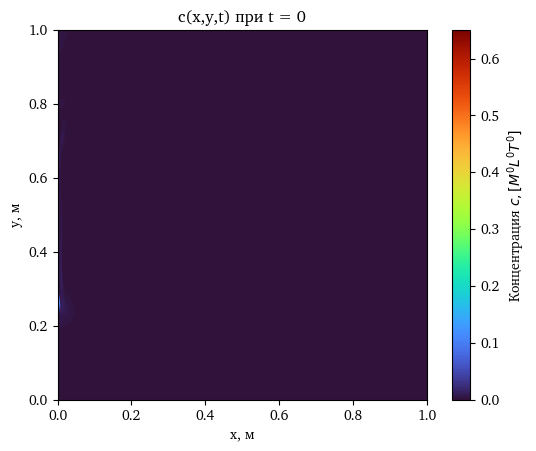

Saving animation to gifs\neural_16.gif ...
Done.


In [70]:
anim_result(c,
            t.max()/Nt,
            clims=[0,cmax],
            streamplot_data=[mesh_xy,mesh_yx,ux,uy],
            # streamplot_data=[mesh_xy,mesh_yx,solver.Vx[:151,:,:-1],solver.Vy[:151,:-1,:]],
            limits = [0, L, H, 0],
            dpi = 100,
            name='neural',
            title='c(x,y,t)',
            colour='turbo',
            path='gifs',
            savetogif=True,
            showMe=True,
            )